# Group analysis of columns data

## Load data

In [1]:
import os

### This is to analyse the data in group
import numpy as np
import pandas as pd
from numexpr.necompiler import default_type

# Import columns data
csv_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/'
subject_list = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/code/subjects_1mm.txt'
subject_group = r'/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'

# Read subject_list to get the subjects indexes
subjects = []
with open(subject_list, 'r') as f:
    for line in f:
        line = line.strip('\n')
        subjects.append(line)

print(subjects)

# Read subject_group to get subjects groups
ad_decode_data2 = pd.read_excel(subject_group, sheet_name='AD_DECODE_data2')
print('Size of the group data:', ad_decode_data2.shape)
print('Columns of the group data:', ad_decode_data2.columns)

['S04493', 'S03847', 'S02227', 'S02451', 'S02812', 'S02686', 'S03010', 'S02877', 'S00775', 'S02802', 'S02842', 'S03867', 'S02695', 'S01470', 'S02421', 'S03350', 'S02373', 'S03896', 'S02967', 'S02654', 'S02390', 'S02231', 'S03033', 'S02506', 'S03378', 'S02320', 'S02446', 'S02410', 'S02954', 'S02524', 'S01619', 'S02469', 'S02361', 'S03265', 'S02110', 'S02715', 'S03391', 'S03890', 'S02898', 'S03293', 'S02939', 'S02289', 'S01412', 'S04526', 'S04738', 'S02535', 'S02473', 'S02817', 'S03069', 'S03321', 'S02871', 'S02402', 'S02813', 'S02737', 'S02491', 'S02424', 'S03308', 'S02938', 'S02670', 'S03045', 'S02386', 'S02840', 'S02690', 'S03889', 'S02771', 'S02781', 'S02666', 'S03028', 'S02720', 'S03034', 'S01912', 'S02485', 'S03017', 'S02266', 'S02363', 'S02765', 'S04696', 'S01621', 'S03225', 'S03343', 'S03866', 'S02804', 'S02753', 'S02224', 'S02926', 'S02987']
Size of the group data: (123, 47)
Columns of the group data: Index(['Subject', 'MRI_Exam', 'age', 'genotype', 'sex', 'Risk', 'risk_for_ad',

In [2]:
# Classified as left and right, risk 0 1 and 2 3, plot individual and averaged curves
# 4 categories in total
import matplotlib.pyplot as plt
import os

region_list = [
    'BA1_exvivo_thresh', 'BA1_exvivo',
    'BA2_exvivo_thresh', 'BA2_exvivo',
    'BA3a_exvivo_thresh', 'BA3a_exvivo',
    'BA3b_exvivo_thresh', 'BA3b_exvivo',
    'BA4a_exvivo_thresh', 'BA4a_exvivo',
    'BA4p_exvivo_thresh', 'BA4p_exvivo',
    'BA6_exvivo_thresh', 'BA6_exvivo',
    'BA44_exvivo_thresh', 'BA44_exvivo',
    'BA45_exvivo_thresh', 'BA45_exvivo',
    'cortex', 'cortex+hipamyg',
    'entorhinal_exvivo_thresh', 'entorhinal_exvivo',
    'FG1_mpm_vpnl', 'FG2_mpm_vpnl',
    'FG3_mpm_vpnl', 'FG4_mpm_vpnl',
    'hOc1_mpm_vpnl', 'hOc2_mpm_vpnl',
    'hOc3v_mpm_vpnl', 'hOc4v_mpm_vpnl',
    'MT_exvivo_thresh', 'MT_exvivo',
    'nofix_cortex',
    'perirhinal_exvivo_thresh', 'perirhinal_exvivo',
    'V1_exvivo_thresh', 'V1_exvivo',
    'V2_exvivo_thresh', 'V2_exvivo'
]
zero_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 0]['MRI_Exam'].tolist()
one_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 1]['MRI_Exam'].tolist()
two_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 2]['MRI_Exam'].tolist()
three_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 3]['MRI_Exam'].tolist()
low_risk_sub = zero_risk_sub + one_risk_sub
high_risk_sub = two_risk_sub + three_risk_sub
print(len(low_risk_sub))
print(len(high_risk_sub))


83
11


In [3]:
left_low_dic = {region: np.empty([1, 21]) for region in region_list}
right_low_dic = {region: np.empty([1, 21]) for region in region_list}
rl_low_dic = {region: np.empty([1, 21]) for region in region_list}
left_high_dic = {region: np.empty([1, 21]) for region in region_list}
right_high_dic = {region: np.empty([1, 21]) for region in region_list}
rl_high_dic = {region: np.empty([1, 21]) for region in region_list}

def get_subject_id(s):
    integer = int(s)
    expected_length = 5
    length = len(str(integer))
    s_id = 'S'
    for i in range(expected_length - length):
        s_id = s_id + '0'
    s_id = s_id + str(integer)
    return s_id

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_md.csv'
        rh_region_name = subject_id + '_rh_' + region + '_md.csv'
        rl_region_name = subject_id + '_rl_' + region + '_md.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for subject in low_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_md.csv'
        rh_region_name = subject_id + '_rh_' + region + '_md.csv'
        rl_region_name = subject_id + '_rl_' + region + '_md.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        # Check if file exit
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            left_low_dic[region] = np.append(left_low_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            right_low_dic[region] = np.append(right_low_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_low_dic[region] = np.append(rl_low_dic[region], column.to_numpy(), axis=0)

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_md.csv'
        rh_region_name = subject_id + '_rh_' + region + '_md.csv'
        rl_region_name = subject_id + '_rl_' + region + '_md.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for region in region_list:
    left_low_dic[region] = left_low_dic[region][1:]
    right_low_dic[region] = right_low_dic[region][1:]
    rl_low_dic[region] = rl_low_dic[region][1:]
    left_high_dic[region] = left_high_dic[region][1:]
    right_high_dic[region] = right_high_dic[region][1:]
    rl_high_dic[region] = rl_high_dic[region][1:]

In [4]:
# Plot the columns
from matplotlib.lines import Line2D
for region in region_list:
    plt.figure()
    for i in range(left_low_dic[region].shape[0]):
        plt.plot(range(21), left_low_dic[region][i], color='b', linewidth=0.1)
    for i in range(right_low_dic[region].shape[0]):
        plt.plot(range(21), right_low_dic[region][i], color='r', linewidth=0.1)
    for i in range(left_high_dic[region].shape[0]):
        plt.plot(range(21), left_high_dic[region][i], color='g', linewidth=0.1)
    for i in range(right_high_dic[region].shape[0]):
        plt.plot(range(21), right_high_dic[region][i], color='c', linewidth=0.1)
    plt.plot(range(21), np.mean(left_low_dic[region], axis=0), color='b', linewidth=2)
    plt.plot(range(21), np.mean(right_low_dic[region], axis=0), color='r', linewidth=2)
    plt.plot(range(21), np.mean(left_high_dic[region], axis=0), color='g', linewidth=2)
    plt.plot(range(21), np.mean(right_high_dic[region], axis=0), color='c', linewidth=2)
    legend_elements = [Line2D([0], [0], color='b', linewidth=0.1, label='left_low_individual'),
                       Line2D([0], [0], color='r', linewidth=0.1, label='right_low_individual'),
                       Line2D([0], [0], color='g', linewidth=0.1, label='left_high_individual'),
                       Line2D([0], [0], color='c', linewidth=0.1, label='right_high_individual'),
                       Line2D([0], [0], color='b', linewidth=2, label='left_low_mean'),
                       Line2D([0], [0], color='r', linewidth=2, label='right_low_mean'),
                       Line2D([0], [0], color='g', linewidth=2, label='left_high_mean'),
                       Line2D([0], [0], color='c', linewidth=2, label='right_high_mean')]
    plt.legend(handles=legend_elements)
    plt.title(region)
    plt.xticks([0, 21], ['WM/GM','Pial'])
    plt.ylabel('MD')
    fig_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/linear_model_analysis/'
    plt.savefig(fig_dir + 'md_' + region + '_1mm.png')
    plt.close()


In [5]:
# Linear Model
valid_subjects = []
left_dic = {region: np.empty([1, 3]) for region in region_list}
right_dic = {region: np.empty([1, 3]) for region in region_list}
for subject in subjects:
    subject_id = subject
    file_valid = 'True'
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_md.csv'
        rh_region_name = subject_id + '_rh_' + region + '_md.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        if not os.path.exists(lh_csv):
            file_valid = 'False'
            print('Subject %s doesnt have lh_csv' % subject_id)
            continue
        if not os.path.exists(rh_csv):
            file_valid = 'False'
            print('Subject %s doesnt have rh_csv' % subject_id)
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                print('NAN found in subject %s lh region %s', subject_id, region)
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            left_dic[region] = np.append(left_dic[region], three_bin, axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                print('NAN found in subject %s rh region %s', subject_id, region)
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            right_dic[region] = np.append(right_dic[region], three_bin, axis=0)
    if file_valid == 'True':
        valid_subjects.append(subject_id)

Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812 doesnt have lh_csv
Subject S02812

In [6]:
valid_subject_index = []
for subject in valid_subjects:
    subject = subject[1:]
    subject_index = int(subject)
    valid_subject_index.append(subject_index)
for region in region_list:
    right_dic[region] = right_dic[region][1:]
    left_dic[region] = left_dic[region][1:]

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
genotype_column = np.empty([0,1])
sex_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    genotype = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['genotype'].values[0]
    sex = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['sex'].values[0]
    if '4' in genotype:
        genotype = 1
    else:
        genotype = 0
    if sex == 'M':
        sex = 1
    else:
        sex = 0
    age_column = np.append(age_column, age)
    genotype_column = np.append(genotype_column, genotype)
    sex_column = np.append(sex_column, sex)

age_column = age_column.reshape((-1, 1))
genotype_column = genotype_column.reshape((-1, 1))
sex_column = sex_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Standard genotype
mu_genotype = np.mean(genotype_column)
sigma_genotype = np.std(genotype_column)
genotype_std = (genotype_column - mu_genotype) / sigma_genotype

# Standard sex
mu_sex = np.mean(sex_column)
sigma_sex = np.std(sex_column)
sex_std = (sex_column - mu_sex) / sigma_sex

# Combine features
X = np.column_stack((age_std, genotype_std, sex_std))
print(X)

[[ 0.69263052 -0.91986621 -0.86953871]
 [-2.06214654  1.08711461  1.15003506]
 [-0.98122326 -0.91986621  1.15003506]
 [-0.33743335 -0.91986621 -0.86953871]
 [ 1.01452548 -0.91986621  1.15003506]
 [-0.53057032  1.08711461 -0.86953871]
 [ 0.93083279 -0.91986621 -0.86953871]
 [-1.75377117  1.08711461 -0.86953871]
 [-1.36749721  1.08711461 -0.86953871]
 [ 0.54198368 -0.91986621 -0.86953871]
 [ 0.1132196   1.08711461 -0.86953871]
 [-0.61941333 -0.91986621  1.15003506]
 [-0.7237073  -0.91986621 -0.86953871]
 [ 1.66668467  1.08711461 -0.86953871]
 [ 1.91583137 -0.91986621 -0.86953871]
 [ 0.24197758  1.08711461  1.15003506]
 [-0.46619133  1.08711461 -0.86953871]
 [-2.01128713 -0.91986621  1.15003506]
 [-1.36749721 -0.91986621 -0.86953871]
 [-0.91684427 -0.91986621 -0.86953871]
 [ 0.84778389  1.08711461 -0.86953871]
 [-1.36749721 -0.91986621  1.15003506]
 [-0.6593283   1.08711461 -0.86953871]
 [ 0.75700952 -0.91986621 -0.86953871]
 [ 0.95014649  1.08711461  1.15003506]
 [ 0.56387254 -0.91986621

lh_BA1_exvivo_thresh
Weights:
[[ 0.0029703  -0.00817823 -0.0006423 ]
 [ 0.00668091 -0.01301702 -0.00855449]
 [ 0.01644654 -0.02080156 -0.00481897]]
MSE:
0.010730723289401849
R2:
0.03303851840737393


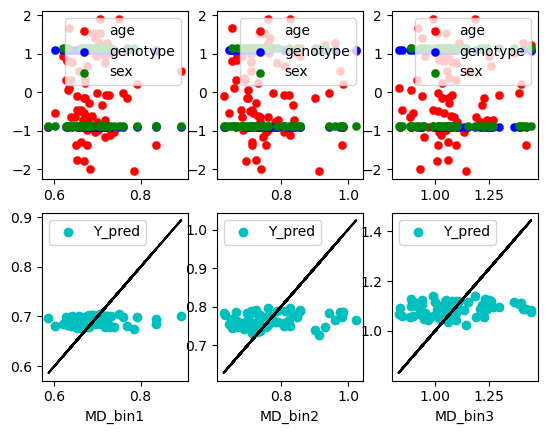

lh_BA1_exvivo
Weights:
[[ 0.00447342 -0.00610585 -0.00536131]
 [ 0.01393216 -0.01064714 -0.00972279]
 [ 0.03874739 -0.01731752  0.0125206 ]]
MSE:
0.005161812606774032
R2:
0.1062909804942479


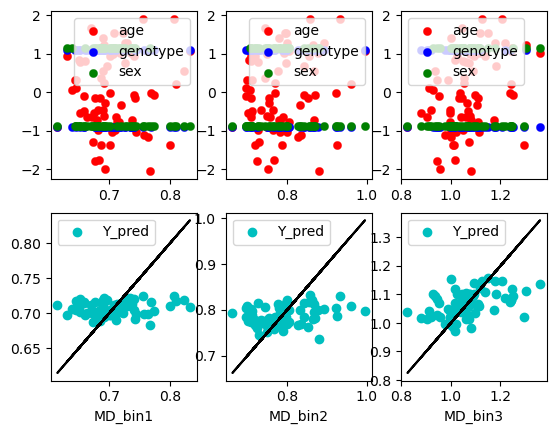

lh_BA2_exvivo_thresh
Weights:
[[ 0.00627049 -0.00677091  0.00828001]
 [ 0.01114692 -0.01206     0.0163116 ]
 [ 0.04257177 -0.0129884   0.07003377]]
MSE:
0.004946476374308029
R2:
0.23751757221669104


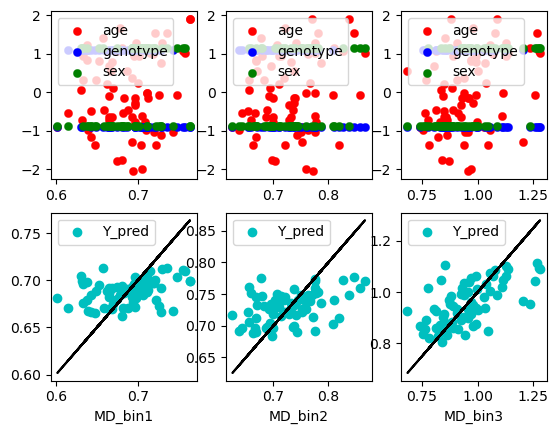

lh_BA2_exvivo
Weights:
[[ 0.00414076 -0.0046332  -0.00439133]
 [ 0.01373111 -0.00790378 -0.00844514]
 [ 0.04738865 -0.01035985  0.01782759]]
MSE:
0.003627530166202304
R2:
0.14865286883131343


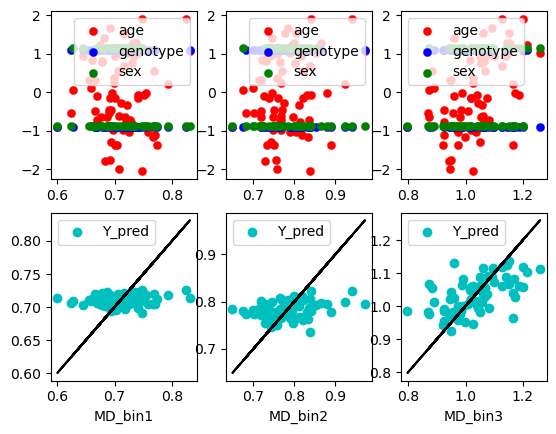

lh_BA3a_exvivo_thresh
Weights:
[[-0.00505293 -0.00694796 -0.0104709 ]
 [ 0.00931046 -0.00837058 -0.00665128]
 [ 0.06105523 -0.01258482  0.02338429]]
MSE:
0.007212306930899704
R2:
0.11807776156177197


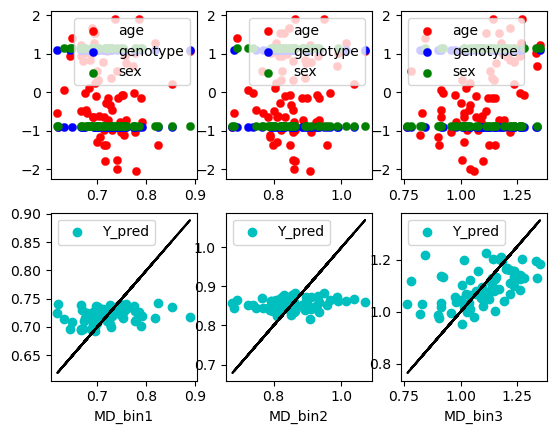

lh_BA3a_exvivo
Weights:
[[-0.00179652 -0.00388035 -0.01390558]
 [ 0.00928527 -0.00430555 -0.01410372]
 [ 0.06044602 -0.01266247  0.01601561]]
MSE:
0.004851144775274519
R2:
0.16529243660786938


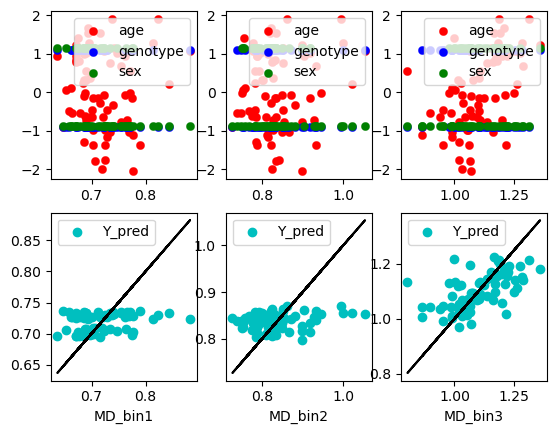

lh_BA3b_exvivo_thresh
Weights:
[[ 0.00813783 -0.00279544 -0.03608157]
 [ 0.03121666  0.00051137 -0.04688826]
 [ 0.09373209 -0.00631413 -0.02322092]]
MSE:
0.02306077600099024
R2:
0.15337750269820868


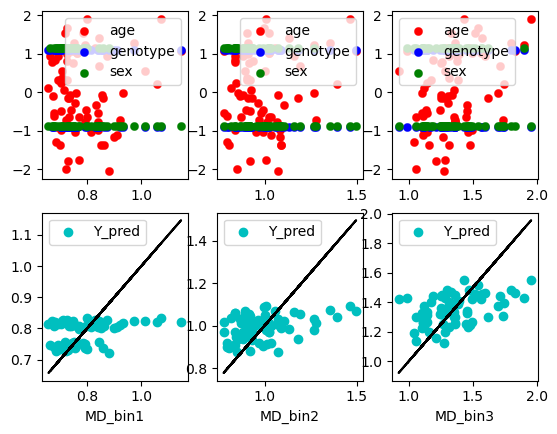

lh_BA3b_exvivo
Weights:
[[ 0.00228415 -0.00304221 -0.01891594]
 [ 0.01699722 -0.00427262 -0.02717703]
 [ 0.06050227 -0.01027172 -0.01183235]]
MSE:
0.008617113260877711
R2:
0.14324310585084157


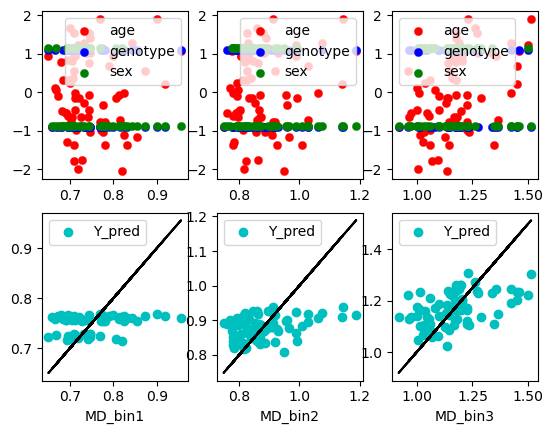

lh_BA4a_exvivo_thresh
Weights:
[[ 0.00453119 -0.00860155  0.00037106]
 [ 0.00849793 -0.01056788  0.00184642]
 [ 0.04481235 -0.02536847  0.04576547]]
MSE:
0.004073814581814755
R2:
0.1822498910614486


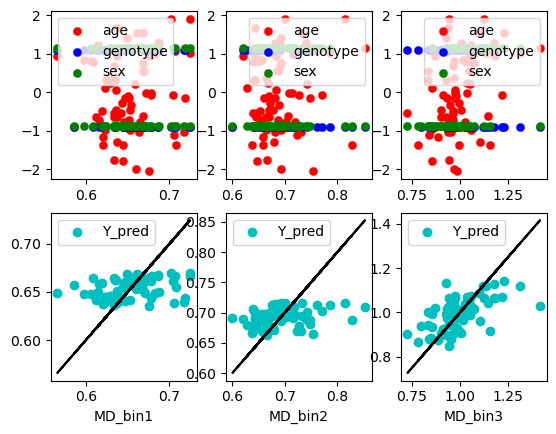

lh_BA4a_exvivo
Weights:
[[ 0.0030465  -0.00815447  0.00076565]
 [ 0.00524728 -0.00867411  0.00015949]
 [ 0.02920928 -0.02324543  0.02907856]]
MSE:
0.0033972952284138528
R2:
0.1285549629942634


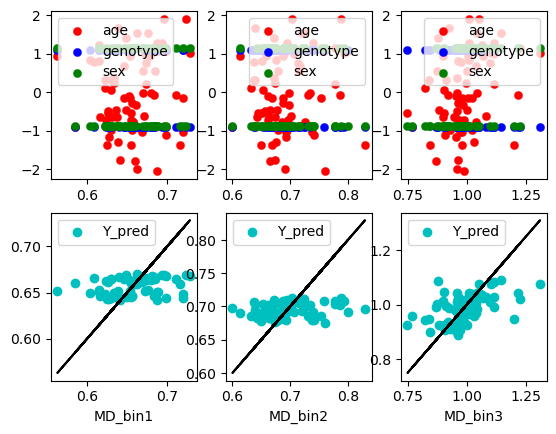

lh_BA4p_exvivo_thresh
Weights:
[[-4.85782889e-05 -6.09515448e-03  2.73997668e-03]
 [-8.34066281e-04 -5.68214701e-03  6.46206734e-03]
 [ 4.62589751e-02 -1.68821672e-02  5.47252863e-02]]
MSE:
0.004176673654927009
R2:
0.15353672888006684


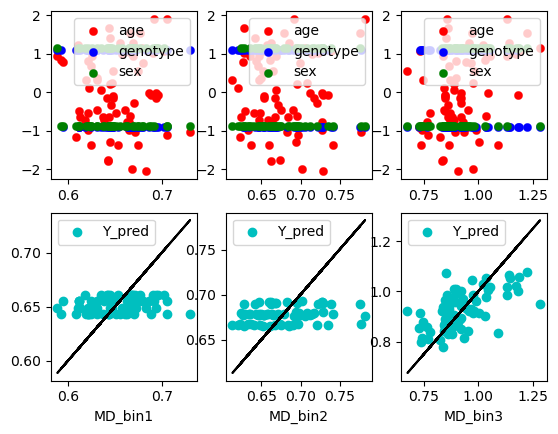

lh_BA4p_exvivo
Weights:
[[ 0.00049754 -0.00757986  0.00132499]
 [ 0.00225428 -0.00931291  0.00461372]
 [ 0.04250383 -0.02113754  0.05196743]]
MSE:
0.004189170843444854
R2:
0.15978054561369173


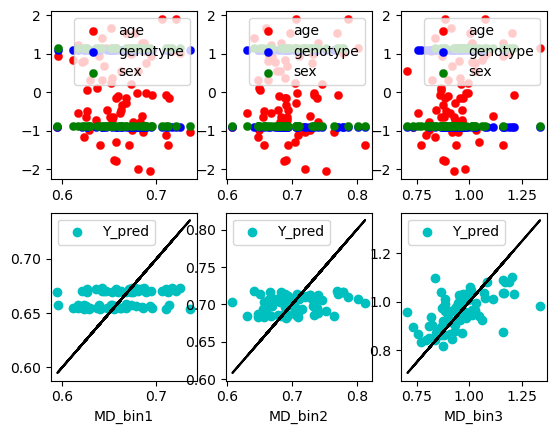

lh_BA6_exvivo_thresh
Weights:
[[ 0.0020594  -0.00802586 -0.00076993]
 [ 0.00474174 -0.01031383 -0.00091065]
 [ 0.0264918  -0.02063402  0.00953038]]
MSE:
0.0035548890062917136
R2:
0.09295921014790576


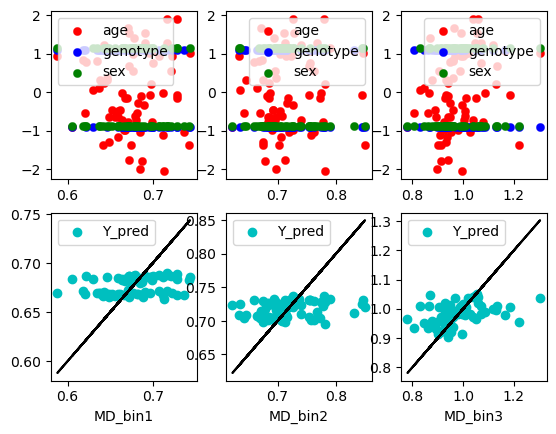

lh_BA6_exvivo
Weights:
[[ 0.00203742 -0.00780075 -0.00209815]
 [ 0.00732306 -0.01011095 -0.00116909]
 [ 0.03601003 -0.01740688  0.01049702]]
MSE:
0.0024900270427805926
R2:
0.14732750366237712


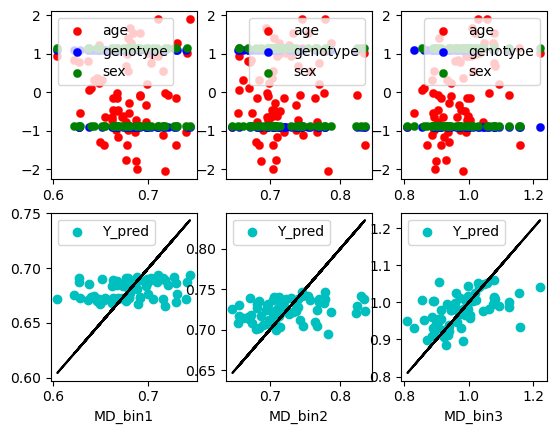

lh_BA44_exvivo_thresh
Weights:
[[-0.00271377 -0.00309153 -0.00354918]
 [ 0.01144872 -0.00550452 -0.01035196]
 [ 0.05550944  0.00357837 -0.00612748]]
MSE:
0.0026718099100154196
R2:
0.17877360247968158


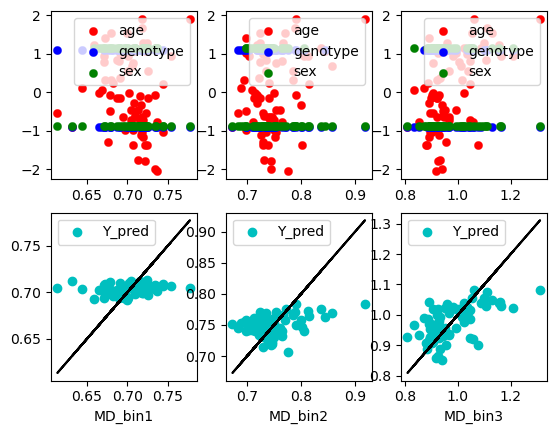

lh_BA44_exvivo
Weights:
[[-0.00216742 -0.00341012 -0.00269939]
 [ 0.01046538 -0.00521722 -0.00855516]
 [ 0.05712624  0.00048597 -0.00380523]]
MSE:
0.002129250759130411
R2:
0.2013444489524198


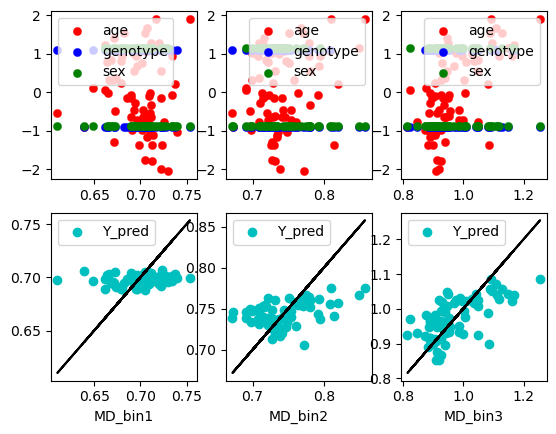

lh_BA45_exvivo_thresh
Weights:
[[ 2.11088405e-03 -3.56386797e-03 -4.61800380e-03]
 [ 1.61424953e-02  3.29660897e-06 -1.31522774e-02]
 [ 5.49813311e-02  1.08505044e-02 -5.97254958e-03]]
MSE:
0.003479094253494671
R2:
0.16210050455423575


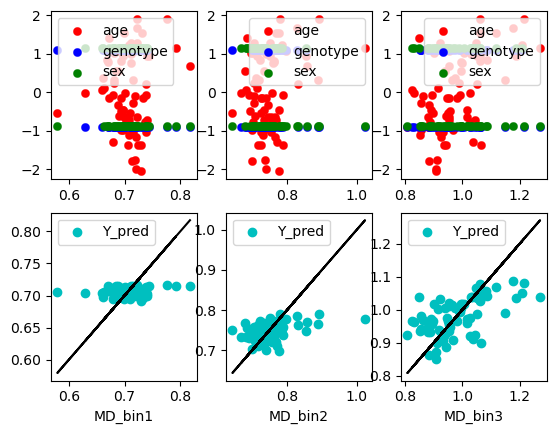

lh_BA45_exvivo
Weights:
[[ 0.00059196 -0.00247535 -0.00427919]
 [ 0.01273676 -0.00225966 -0.00919772]
 [ 0.05154605  0.00658364  0.00255456]]
MSE:
0.002125307221236266
R2:
0.18874926449050813


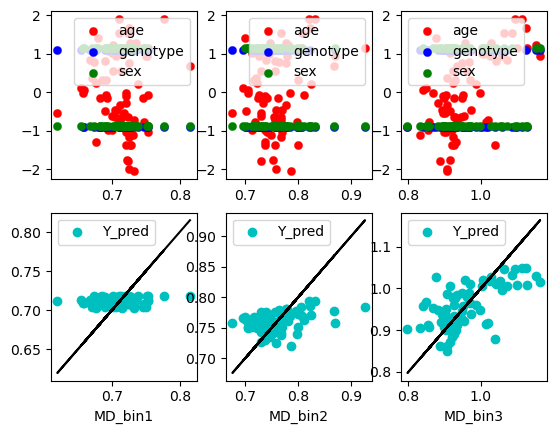

lh_cortex
Weights:
[[ 6.58059199e-03 -1.06627816e-03 -2.04402763e-03]
 [ 1.63091713e-02 -2.11242420e-03 -3.11528851e-06]
 [ 5.23599015e-02 -3.99121483e-03  1.34235735e-02]]
MSE:
0.0011659001312921964
R2:
0.3069195181017635


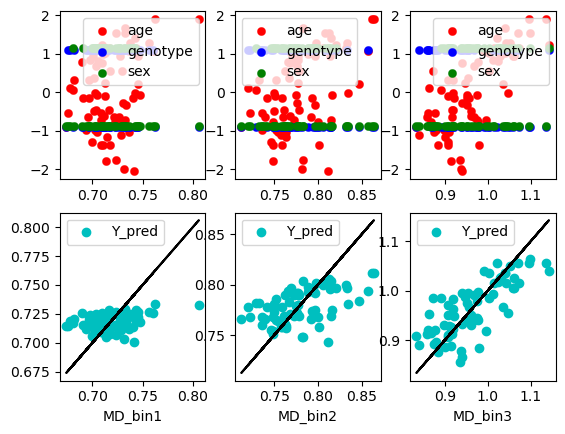

lh_cortex+hipamyg
Weights:
[[ 0.00626465 -0.00105616 -0.00218059]
 [ 0.01596818 -0.00207657 -0.00011079]
 [ 0.05184987 -0.00390953  0.01329724]]
MSE:
0.0011433591150798513
R2:
0.30390644970998576


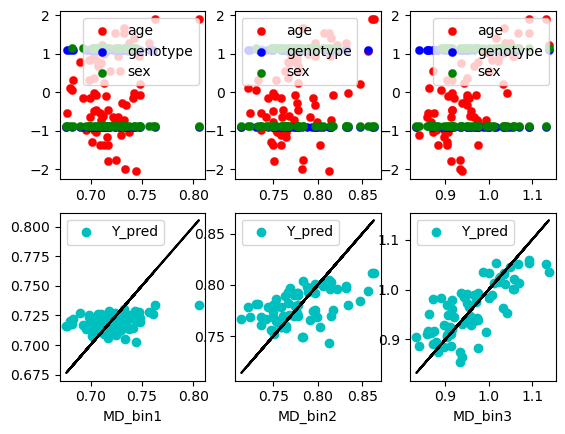

lh_entorhinal_exvivo_thresh
Weights:
[[ 0.00212937  0.0019079  -0.01662519]
 [ 0.01943552 -0.00059376 -0.01721596]
 [ 0.05700594 -0.00476    -0.01218159]]
MSE:
0.006820169593612075
R2:
0.1397844184541195


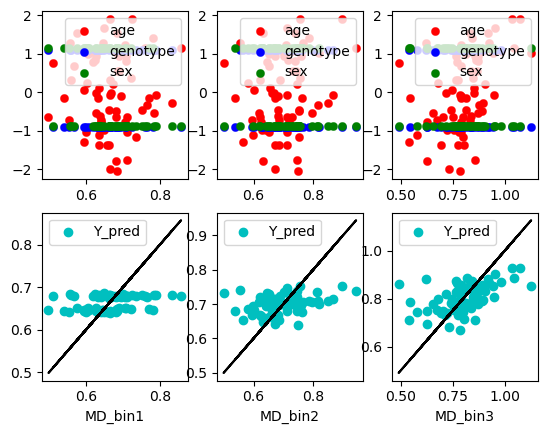

lh_entorhinal_exvivo
Weights:
[[ 0.00471136 -0.00185348 -0.01606239]
 [ 0.01963132 -0.0024691  -0.01317054]
 [ 0.04579469 -0.00274746 -0.01208108]]
MSE:
0.0033357334323408368
R2:
0.19878317849016194


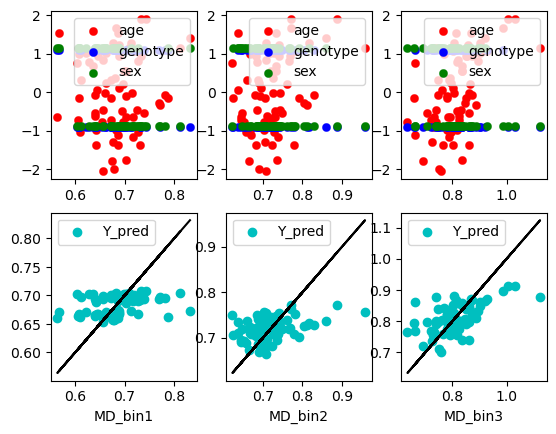

lh_FG1_mpm_vpnl
Weights:
[[ 0.00851753  0.00156604 -0.00435508]
 [ 0.02640499  0.00238907  0.00570502]
 [ 0.06089323  0.00530565  0.01135975]]
MSE:
0.004373607653100519
R2:
0.19080393672263632


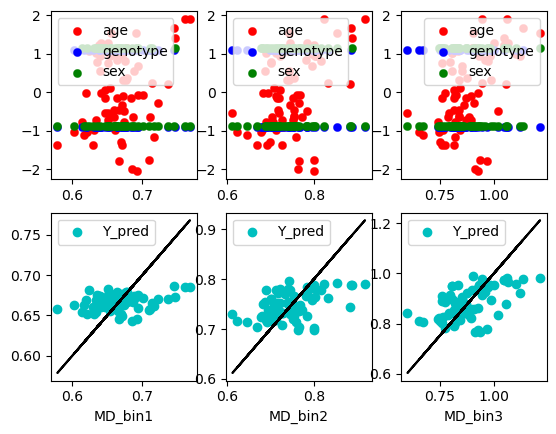

lh_FG2_mpm_vpnl
Weights:
[[ 0.01000043  0.00622158 -0.00409046]
 [ 0.0266556   0.00561452  0.00077309]
 [ 0.06109575  0.00610118  0.00759836]]
MSE:
0.003693225835602976
R2:
0.21380210652177067


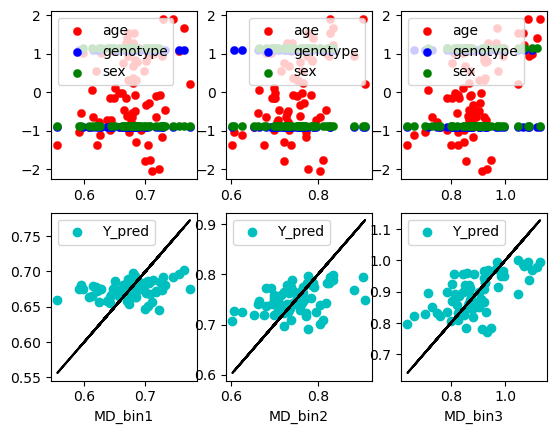

lh_FG3_mpm_vpnl
Weights:
[[ 0.00417072 -0.00174227 -0.00469464]
 [ 0.02586183 -0.00173612  0.0034868 ]
 [ 0.07963034  0.00320666  0.01417648]]
MSE:
0.0022731270809851463
R2:
0.31487204209721004


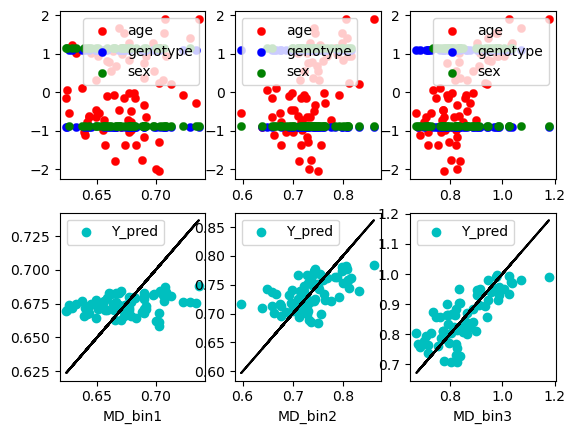

lh_FG4_mpm_vpnl
Weights:
[[ 0.00876453  0.00196667 -0.00061354]
 [ 0.01988641  0.00420831  0.00496447]
 [ 0.06142402  0.00078409  0.01183907]]
MSE:
0.0026116594610950516
R2:
0.2362897050222942


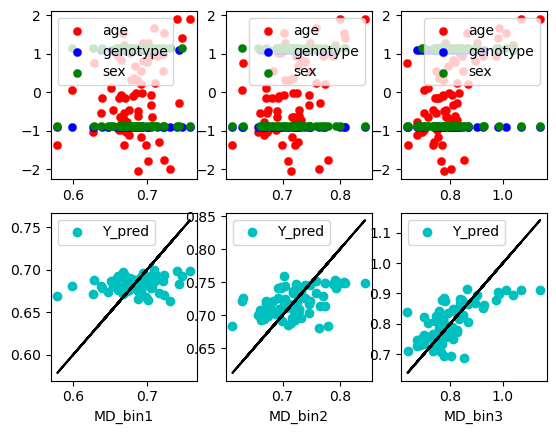

lh_hOc1_mpm_vpnl
Weights:
[[ 0.0229973  -0.00200194 -0.00436785]
 [ 0.03889242 -0.00553444  0.01347759]
 [ 0.06273591  0.00029396  0.03911973]]
MSE:
0.00363628930508755
R2:
0.356015689799318


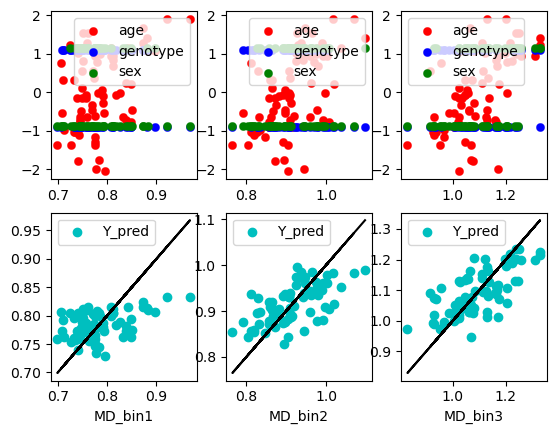

lh_hOc2_mpm_vpnl
Weights:
[[ 0.01684264 -0.00069242 -0.00080047]
 [ 0.03006316 -0.00455326  0.01573275]
 [ 0.05448646 -0.0034862   0.04645204]]
MSE:
0.004096671001946728
R2:
0.27195744863935


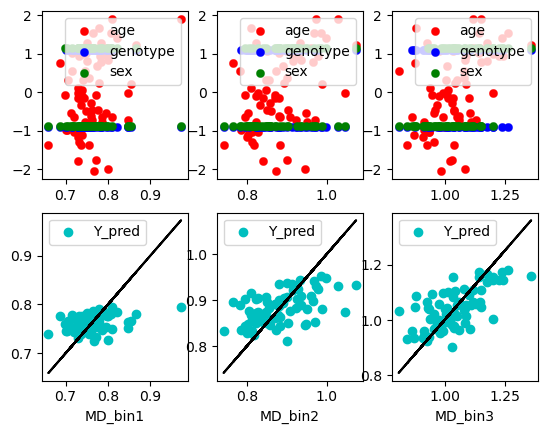

lh_hOc3v_mpm_vpnl
Weights:
[[0.02219965 0.0084049  0.00257757]
 [0.02630497 0.00648818 0.00894412]
 [0.04405592 0.00554676 0.02215614]]
MSE:
0.005555224692107093
R2:
0.1724604212328923


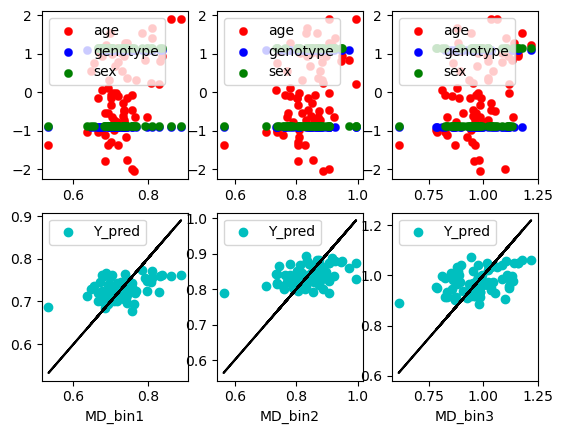

lh_hOc4v_mpm_vpnl
Weights:
[[ 0.02052992  0.00310228 -0.00181376]
 [ 0.03563456  0.00268093  0.01408473]
 [ 0.05988646  0.00369658  0.02629611]]
MSE:
0.004782421914209677
R2:
0.2598419323337921


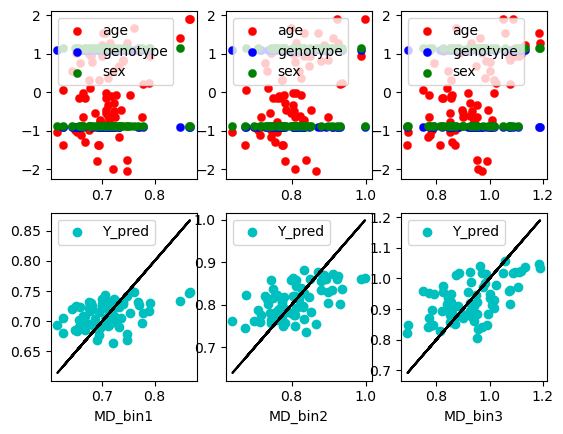

lh_MT_exvivo_thresh
Weights:
[[ 0.00350896  0.00443033 -0.00301643]
 [ 0.01628663 -0.00030121  0.00091163]
 [ 0.05646651  0.00044433  0.02824232]]
MSE:
0.004903822074766705
R2:
0.1296795047042194


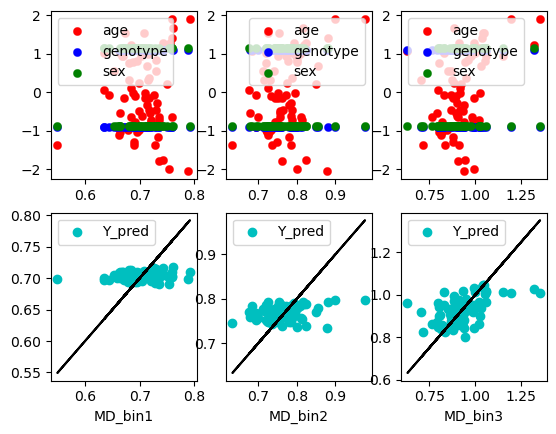

lh_MT_exvivo
Weights:
[[ 0.00531209  0.00498929 -0.00432943]
 [ 0.01712045  0.00151377 -0.00369772]
 [ 0.0579634   0.0008721   0.01699341]]
MSE:
0.0034404256829531086
R2:
0.17416418131884567


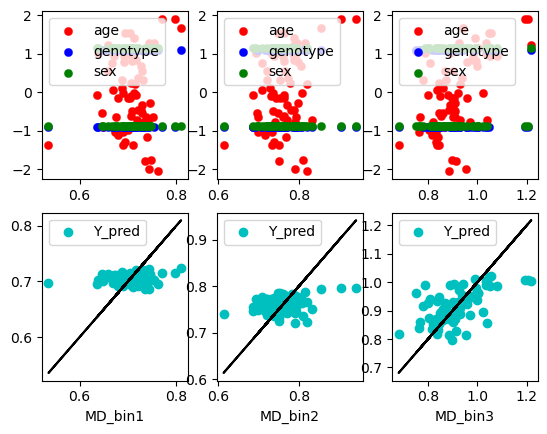

lh_nofix_cortex
Weights:
[[ 0.0109204  -0.00128549 -0.00258288]
 [ 0.02005104 -0.00229102 -0.00050116]
 [ 0.05369661 -0.00397445  0.01263447]]
MSE:
0.001204278041621264
R2:
0.36776922801422934


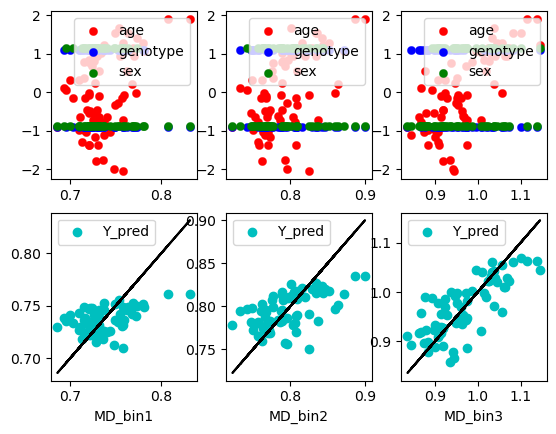

lh_perirhinal_exvivo_thresh
Weights:
[[ 0.00463134 -0.00300056 -0.01340199]
 [ 0.00905185  0.00236162 -0.00805506]
 [ 0.0266156   0.00438373 -0.00690709]]
MSE:
0.003190344289229089
R2:
0.0948917079860866


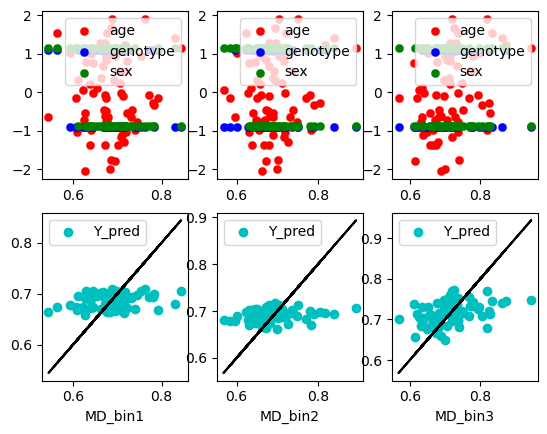

lh_perirhinal_exvivo
Weights:
[[ 0.00393228 -0.00343305 -0.01463714]
 [ 0.01216119 -0.00238562 -0.01224566]
 [ 0.03270058 -0.00318163 -0.00952572]]
MSE:
0.0030385174683065733
R2:
0.14017218203627177


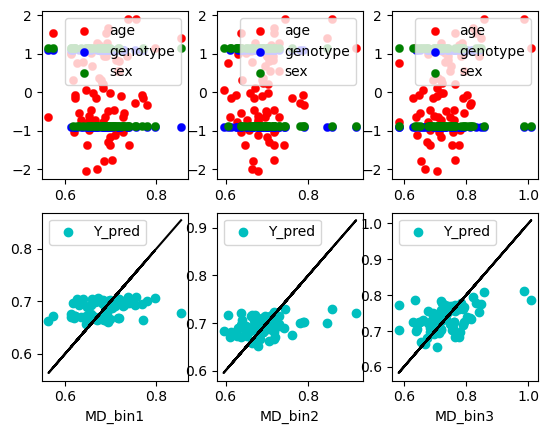

lh_V1_exvivo_thresh
Weights:
[[ 0.02195164 -0.00124393 -0.0072586 ]
 [ 0.03771603 -0.00554968  0.01045983]
 [ 0.0620961  -0.00055029  0.03748488]]
MSE:
0.0038420735900958607
R2:
0.3317395760513593


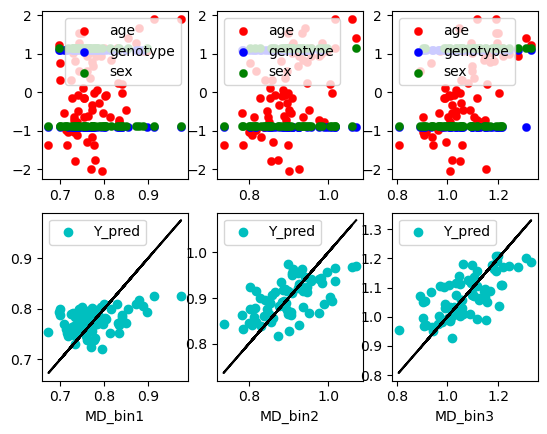

lh_V1_exvivo
Weights:
[[ 0.02038042 -0.00132871 -0.00458732]
 [ 0.03554388 -0.00433916  0.01252245]
 [ 0.0583347   0.00034032  0.04006039]]
MSE:
0.003792233704366141
R2:
0.31574644298312865


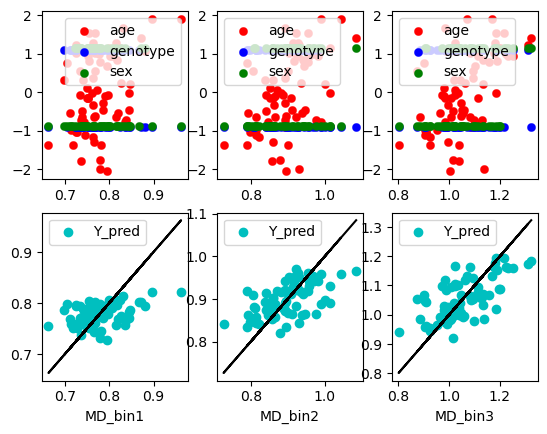

lh_V2_exvivo_thresh
Weights:
[[ 2.03445492e-02 -7.12692958e-05  4.99269939e-03]
 [ 3.24000848e-02 -2.46307565e-03  2.11829059e-02]
 [ 5.18870361e-02 -7.42862639e-04  4.55421814e-02]]
MSE:
0.004358210724093323
R2:
0.28999161125183104


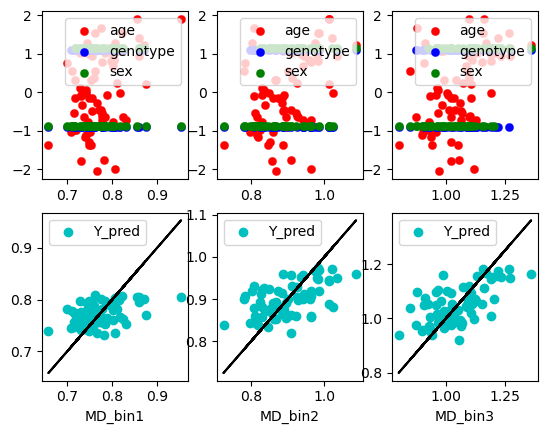

lh_V2_exvivo
Weights:
[[ 0.01916212  0.00109549 -0.00020082]
 [ 0.03161777 -0.00187151  0.01360406]
 [ 0.05609299 -0.00084495  0.03624766]]
MSE:
0.0033501637048833654
R2:
0.31064269131879385


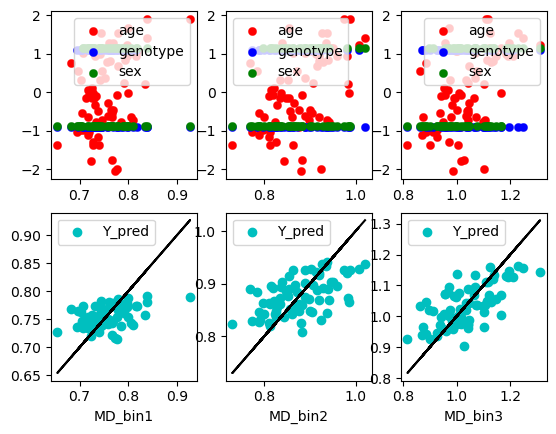

In [8]:
from sklearn.metrics import r2_score
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y = left_dic[region]
    linear_model = LinearRegression()
    linear_model.fit(X, Y)
    r2 = linear_model.score(X, Y)
    weights = linear_model.coef_
    Y_pred = linear_model.predict(X)
    mse = np.mean((Y_pred - Y) ** 2)
    print('Weights:')
    print(weights)
    print('MSE:')
    print(mse)
    print('R2:')
    print(r2)
    plt.subplot(2, 3, 1)
    plt.scatter(Y[:,0], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,0], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,0], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 4)
    plt.scatter(Y[:,0], Y_pred[:,0], label='Y_pred', color='c')
    plt.plot(Y[:,0], Y[:,0], color='k')
    plt.legend()
    plt.xlabel('MD_bin1')
    plt.subplot(2, 3, 2)
    plt.scatter(Y[:,1], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,1], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,1], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 5)
    plt.scatter(Y[:,1], Y_pred[:,1], label='Y_pred', color='c')
    plt.plot(Y[:,1], Y[:,1], color='k')
    plt.legend()
    plt.xlabel('MD_bin2')
    plt.subplot(2, 3, 3)
    plt.scatter(Y[:,2], X[:,0], label='age', color='r', linewidths=0.2)
    plt.scatter(Y[:,2], X[:,1], label='genotype', color='b', linewidths=0.2)
    plt.scatter(Y[:,2], X[:,2], label='sex', color='g', linewidths=0.2)
    plt.legend()
    plt.subplot(2, 3, 6)
    plt.scatter(Y[:,2], Y_pred[:,2], label='Y_pred', color='c')
    plt.plot(Y[:,2], Y[:,2], color='k')
    plt.legend()
    plt.xlabel('MD_bin3')
    plt.show()



In [9]:
# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    age_column = np.append(age_column, age)

age_column = age_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Combine features
X = age_column
print(X)

[[63.        ]
 [20.21      ]
 [37.        ]
 [47.        ]
 [68.        ]
 [44.        ]
 [66.7       ]
 [25.        ]
 [31.        ]
 [60.66      ]
 [54.        ]
 [42.62      ]
 [41.        ]
 [78.13      ]
 [82.        ]
 [56.        ]
 [45.        ]
 [21.        ]
 [31.        ]
 [38.        ]
 [65.41      ]
 [31.        ]
 [42.        ]
 [64.        ]
 [67.        ]
 [61.        ]
 [36.92777778]
 [71.26      ]
 [40.        ]
 [44.        ]
 [76.        ]
 [81.65      ]
 [36.        ]
 [67.86      ]
 [72.        ]
 [55.4       ]
 [44.78      ]
 [76.        ]
 [52.        ]
 [57.        ]
 [41.        ]
 [50.        ]
 [32.        ]
 [34.        ]
 [38.        ]
 [48.        ]
 [64.45      ]
 [53.        ]
 [65.        ]
 [45.        ]
 [42.        ]
 [51.        ]
 [58.        ]
 [50.88      ]
 [57.        ]
 [35.        ]
 [50.        ]
 [42.        ]
 [70.        ]
 [70.        ]
 [36.        ]
 [51.        ]
 [68.        ]
 [72.        ]
 [50.        ]
 [67.04      ]
 [69.     

lh_BA1_exvivo_thresh
Weights:
[[0.00024732]] [[0.0005221]] [[0.00120264]]
MSE:
0.0027725243521744707 0.008309726665581088 0.02183847027474591
R2:
0.005294860404778334 0.007852652549487305 0.015728083061756104


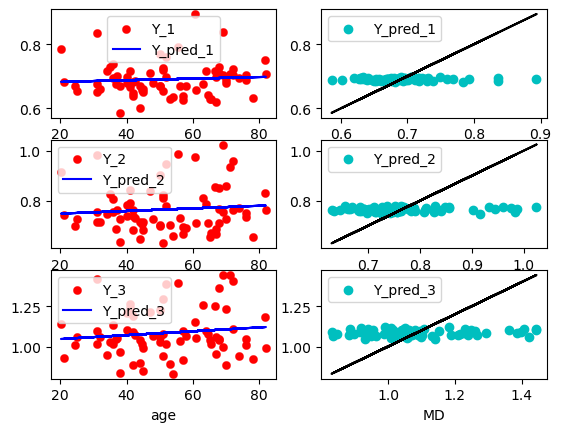

lh_BA1_exvivo
Weights:
[[0.00033163]] [[0.00097316]] [[0.00260831]]
MSE:
0.0020420205565758126 0.004835935025074706 0.009344039132426783
R2:
0.012827871665589852 0.04511835086010829 0.14942088366141792


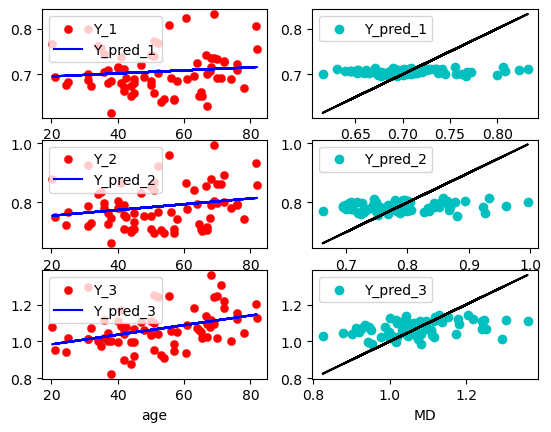

lh_BA2_exvivo_thresh
Weights:
[[0.00044696]] [[0.00079415]] [[0.00280428]]
MSE:
0.0012605596238209184 0.002834238751827828 0.016499276872936335
R2:
0.03682948414716536 0.05095232183455245 0.10313697198274796


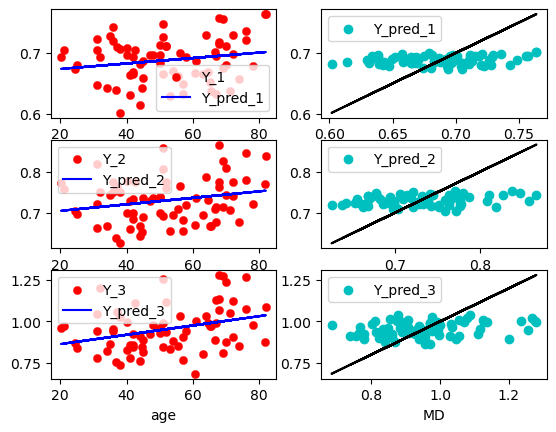

lh_BA2_exvivo
Weights:
[[0.00029981]] [[0.00094102]] [[0.00311519]]
MSE:
0.0016780293438411937 0.0032807084639269114 0.006534769507454271
R2:
0.012758975893142122 0.06114246249678712 0.26378766253268093


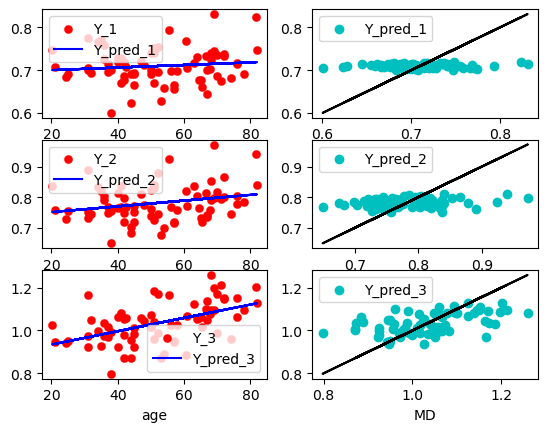

lh_BA3a_exvivo_thresh
Weights:
[[-0.00027408]] [[0.00065897]] [[0.00400824]]
MSE:
0.002480754995806642 0.0056534147050537765 0.014499797622357043
R2:
0.007252879778351318 0.018195150449163977 0.21094276441577875


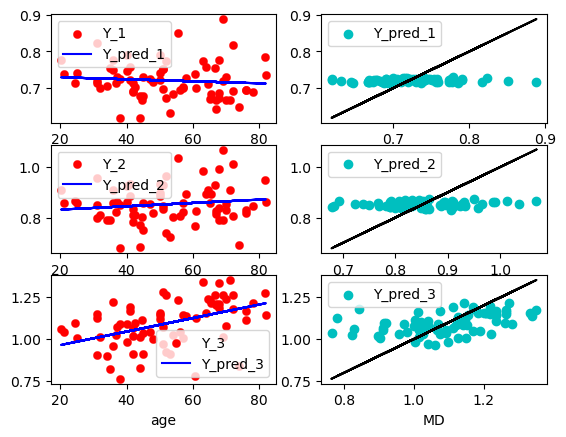

lh_BA3a_exvivo
Weights:
[[-8.41524506e-05]] [[0.00063226]] [[0.00397219]]
MSE:
0.002174448800195467 0.004273599685303175 0.008957987250613357
R2:
0.0007851540659064016 0.022070572018722534 0.2982327113748646


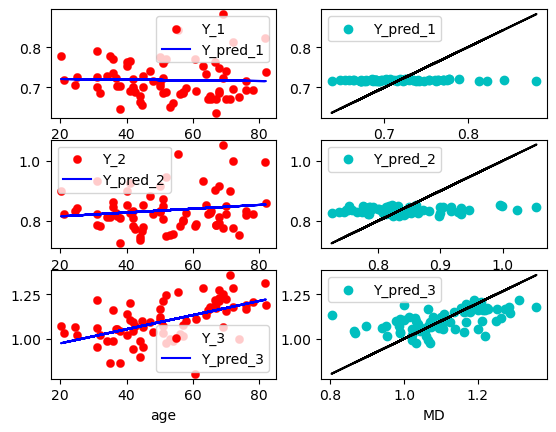

lh_BA3b_exvivo_thresh
Weights:
[[0.00055597]] [[0.00202306]] [[0.00608586]]
MSE:
0.010104623313079134 0.023676759152281283 0.0394571513114408
R2:
0.007326614183474356 0.0400369456960461 0.1846583768187402


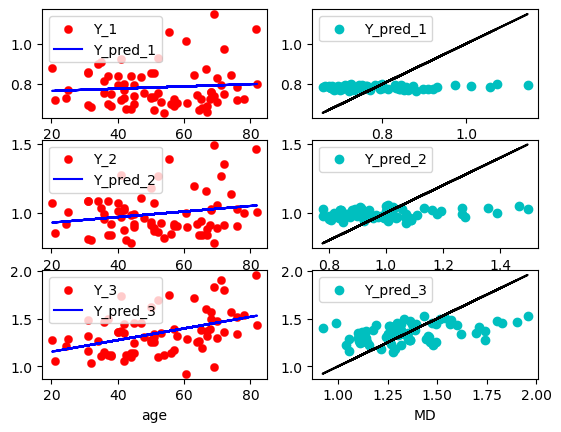

lh_BA3b_exvivo
Weights:
[[0.00017463]] [[0.00113322]] [[0.00396949]]
MSE:
0.0038905338587959517 0.008680468023804908 0.014607718002102857
R2:
0.0018876953218263104 0.0344639757802746 0.20651005801575129


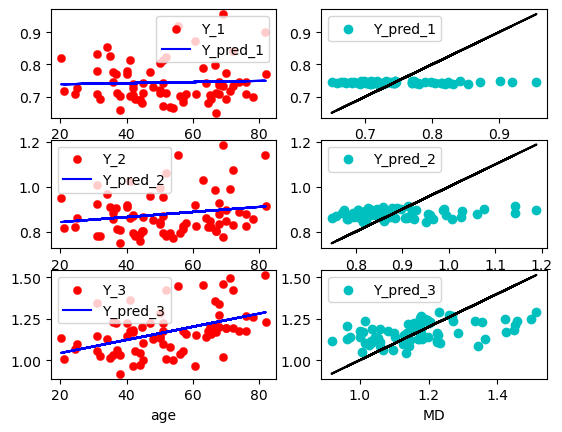

lh_BA4a_exvivo_thresh
Weights:
[[0.00035034]] [[0.00061861]] [[0.00304181]]
MSE:
0.001040752549608389 0.002153996920430936 0.012106985487925402
R2:
0.02766640700629308 0.04110338527793378 0.15568467775194472


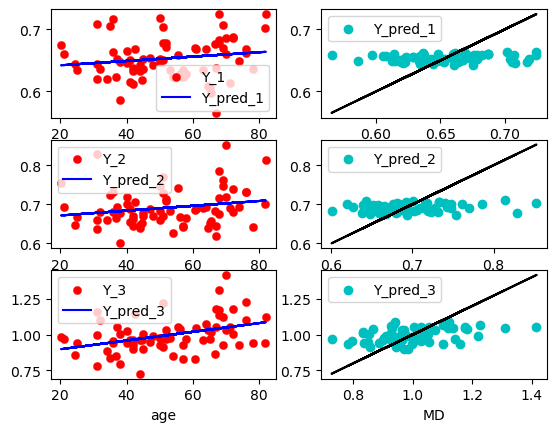

lh_BA4a_exvivo
Weights:
[[0.00025156]] [[0.00039701]] [[0.0020288]]
MSE:
0.0010484496082579899 0.002086996820338178 0.00867080014268119
R2:
0.01435367447047664 0.017895759098965902 0.10276335772410583


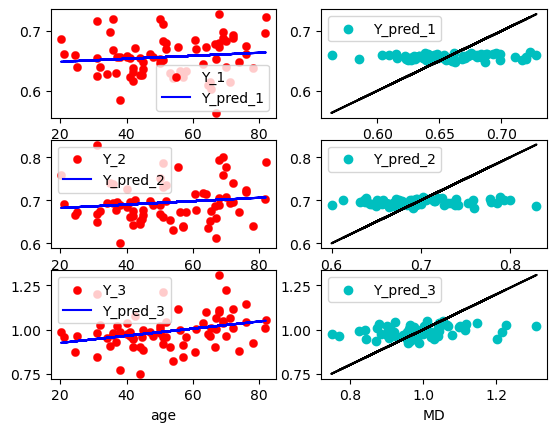

lh_BA4p_exvivo_thresh
Weights:
[[3.75237116e-05]] [[-1.72044726e-05]] [[0.00307376]]
MSE:
0.0008919247982367662 0.001575766339372284 0.013590928693657188
R2:
0.0003807409708179721 4.531926744444359e-05 0.1436349908166693


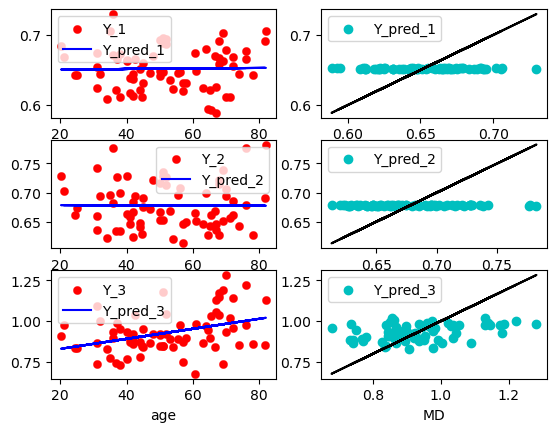

lh_BA4p_exvivo
Weights:
[[8.33329525e-05]] [[0.00020709]] [[0.00286206]]
MSE:
0.0009572515791693892 0.0017114101954073104 0.013364766647383779
R2:
0.0017472683560508795 0.0060095676753995075 0.12882865231098484


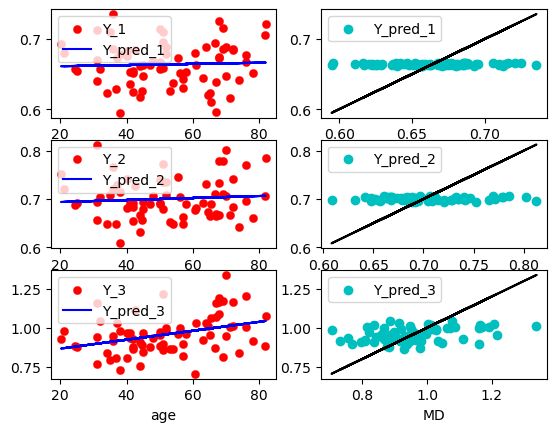

lh_BA6_exvivo_thresh
Weights:
[[0.00018768]] [[0.00037605]] [[0.00184304]]
MSE:
0.0010835780603497165 0.00240431781583507 0.007883703813868211
R2:
0.0077823664210566745 0.013992340104413081 0.09416710929678362


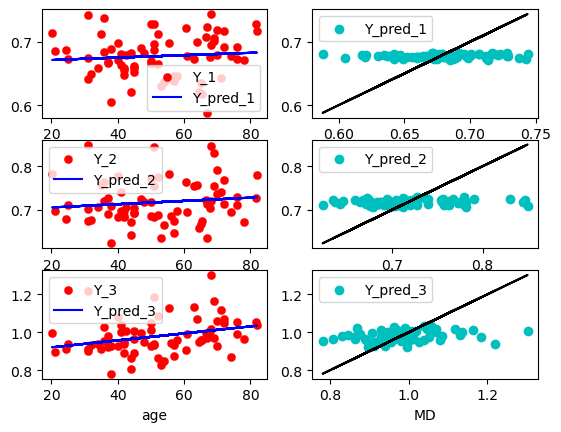

lh_BA6_exvivo
Weights:
[[0.00018521]] [[0.00054094]] [[0.00243342]]
MSE:
0.00092333904781016 0.0019260731471813608 0.005218663510030466
R2:
0.00888371753069317 0.035359138282015756 0.21492956719854484


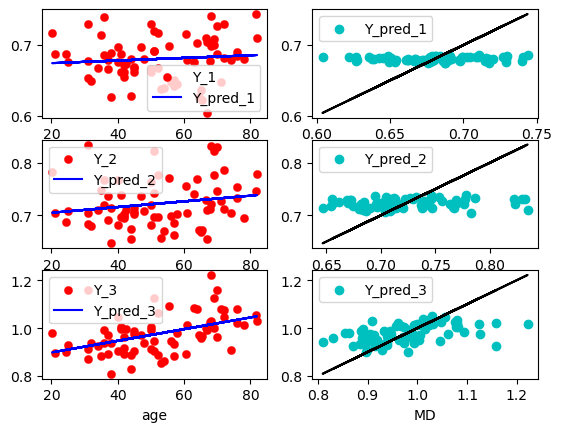

lh_BA44_exvivo_thresh
Weights:
[[-0.00015232]] [[0.00077838]] [[0.0035514]]
MSE:
0.0007317390874857207 0.0016765018527314644 0.005810242258821183
R2:
0.00759160236842471 0.08020166714595223 0.3437206088181989


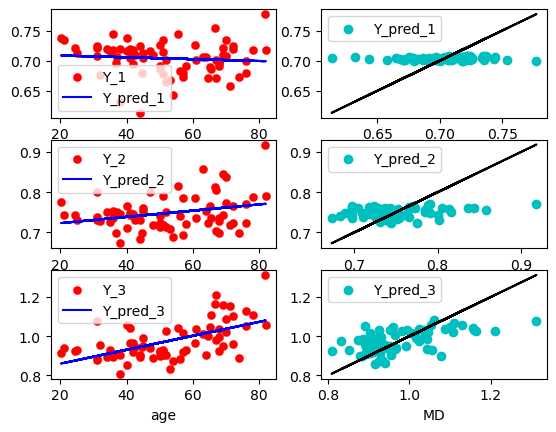

lh_BA44_exvivo
Weights:
[[-0.00011527]] [[0.00071247]] [[0.00367578]]
MSE:
0.0005965317324649308 0.0012719444641634 0.004645740215790662
R2:
0.005345560171120534 0.08783064453336831 0.4123544951343273


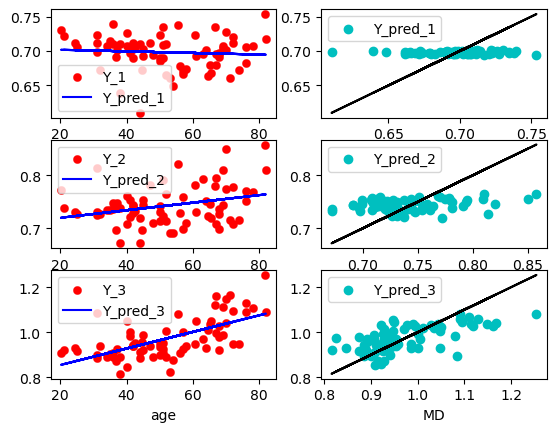

lh_BA45_exvivo_thresh
Weights:
[[0.0001619]] [[0.00104394]] [[0.00346767]]
MSE:
0.001067162904878604 0.003057909748017162 0.006677789459947288
R2:
0.005891371417186542 0.07917996446282982 0.30287578393624437


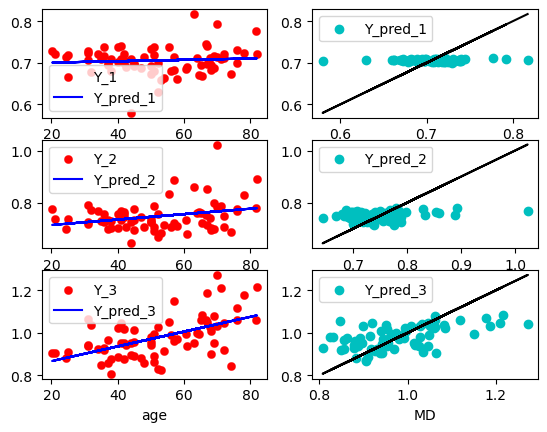

lh_BA45_exvivo
Weights:
[[5.65572265e-05]] [[0.00083872]] [[0.00327259]]
MSE:
0.0008672488456477439 0.0016968972341562776 0.0039685569173537666
R2:
0.0008891147722004389 0.09092665891786345 0.39435140085514053


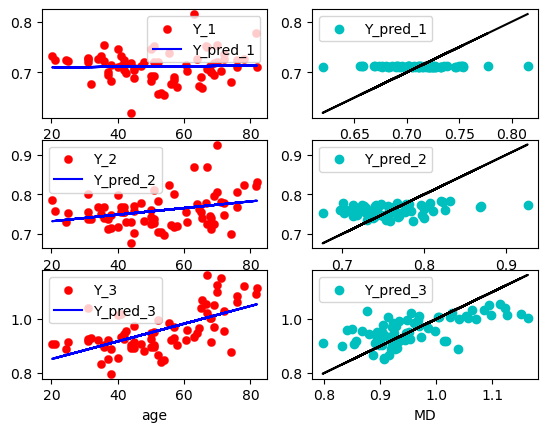

lh_cortex
Weights:
[[0.00043167]] [[0.0010644]] [[0.00339332]]
MSE:
0.00046037396422756626 0.0008607420340866241 0.002389288085478794
R2:
0.08896898520091279 0.24103049377006203 0.5376288396507347


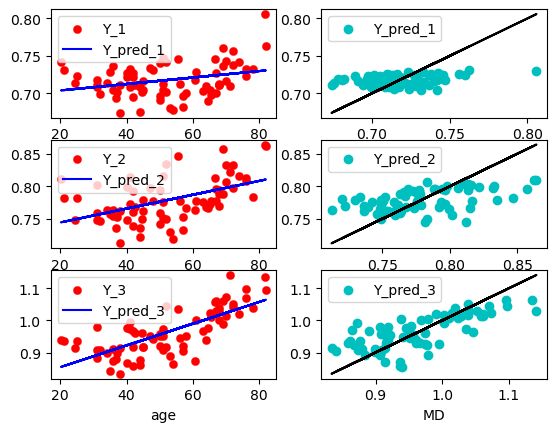

lh_cortex+hipamyg
Weights:
[[0.00041131]] [[0.00104224]] [[0.00335997]]
MSE:
0.00045008421809209203 0.0008455933817680672 0.0023432431940773255
R2:
0.08314887045865105 0.23660959410826665 0.5375560206074175


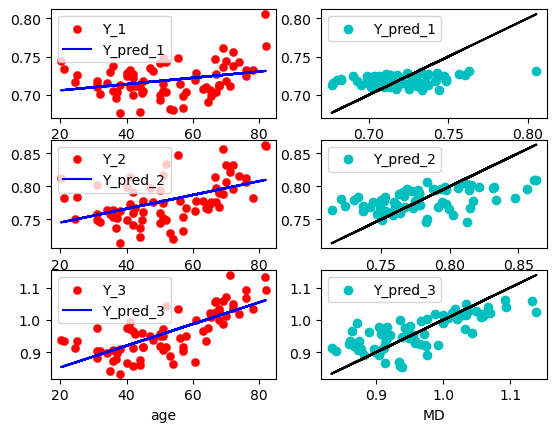

lh_entorhinal_exvivo_thresh
Weights:
[[0.00013003]] [[0.00126148]] [[0.00370688]]
MSE:
0.004681156069042086 0.006016627993957669 0.01050522254205901
R2:
0.0008706957636852586 0.05998681219701851 0.2398848409466925


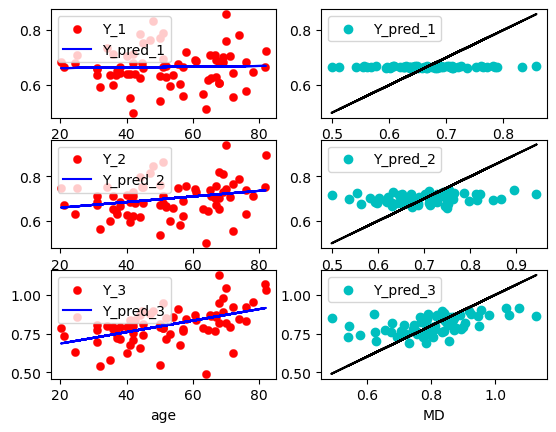

lh_entorhinal_exvivo
Weights:
[[0.00032175]] [[0.00128545]] [[0.00297133]]
MSE:
0.0026154498206381813 0.0031539769291316997 0.004818956475875402
R2:
0.009459526489783876 0.11221903415313106 0.3065369361525786


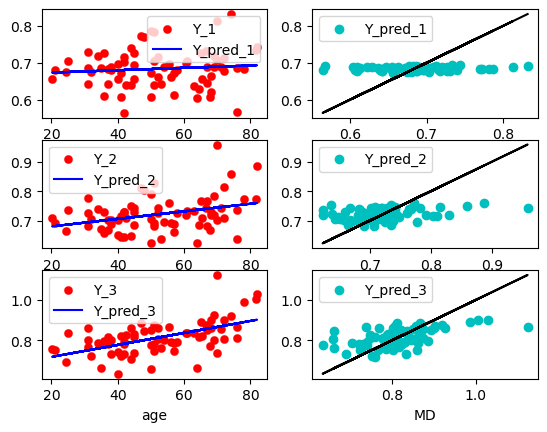

lh_FG1_mpm_vpnl
Weights:
[[0.00053922]] [[0.00168156]] [[0.00387992]]
MSE:
0.001210220959464891 0.0027498691694512974 0.009367980821075095
R2:
0.05479024472293659 0.19878052543628988 0.27939012634101046


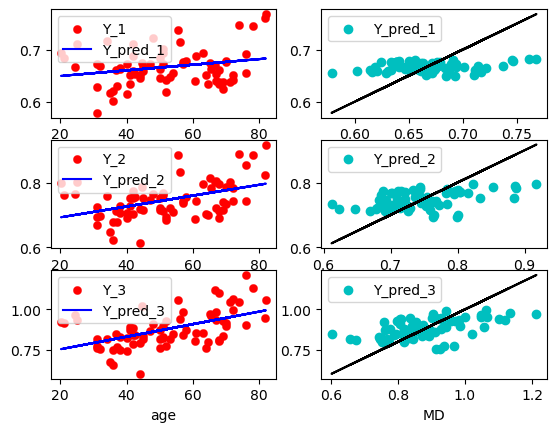

lh_FG2_mpm_vpnl
Weights:
[[0.00060279]] [[0.00167743]] [[0.00388887]]
MSE:
0.001641087952465078 0.0030118538685495405 0.006604578363957
R2:
0.05071167733747073 0.18394426783277418 0.3558681759228839


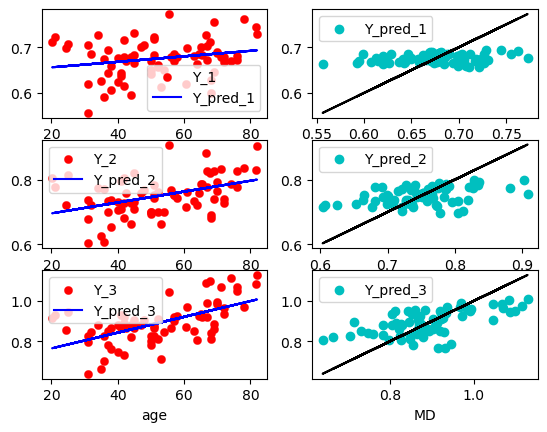

lh_FG3_mpm_vpnl
Weights:
[[0.0002821]] [[0.00167556]] [[0.00509952]]
MSE:
0.000685597911642082 0.0016965362097300968 0.004682027930039177
R2:
0.02724211151912448 0.28534360124073166 0.5726673005015956


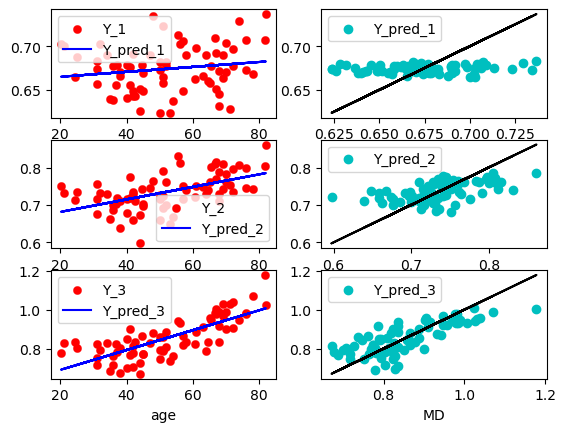

lh_FG4_mpm_vpnl
Weights:
[[0.00055104]] [[0.00124974]] [[0.0039448]]
MSE:
0.0009183593224161726 0.0016115515512979716 0.005488215593943246
R2:
0.07388037191859598 0.18951680716819064 0.40621760020029807


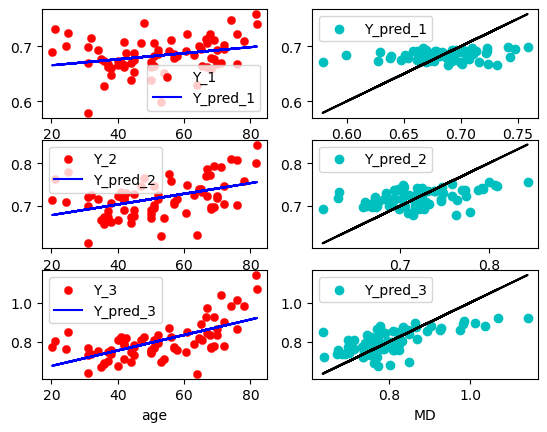

lh_hOc1_mpm_vpnl
Weights:
[[0.00149579]] [[0.00253682]] [[0.0040228]]
MSE:
0.002272461524930655 0.003041717626055764 0.007367502778155848
R2:
0.19195192974291964 0.3379546152571685 0.34639123974410424


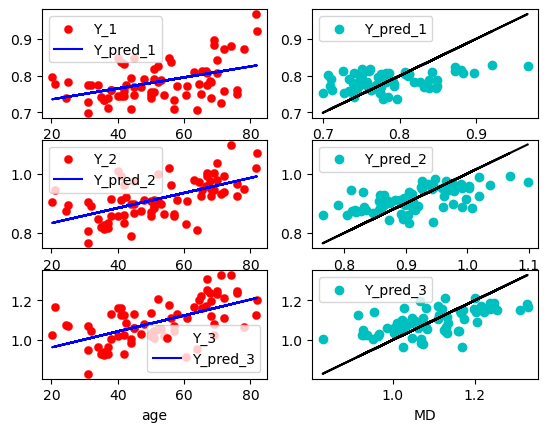

lh_hOc2_mpm_vpnl
Weights:
[[0.00108933]] [[0.00196088]] [[0.0035149]]
MSE:
0.001875715874913741 0.003841573216081473 0.0090435684531833
R2:
0.13242512864793488 0.19451885184693918 0.2478986007059436


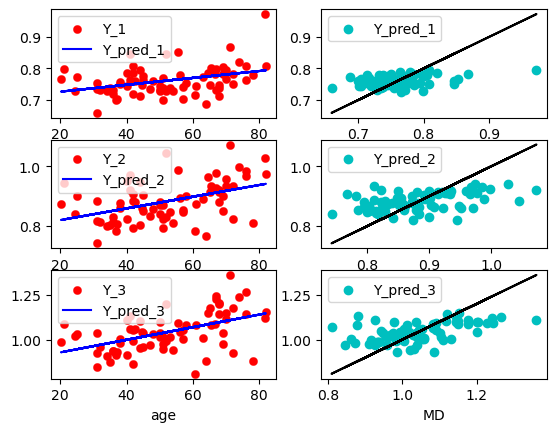

lh_hOc3v_mpm_vpnl
Weights:
[[0.00137085]] [[0.00164595]] [[0.00279042]]
MSE:
0.0026651739960097164 0.004345660066085006 0.010346445441869316
R2:
0.1453899018621766 0.13074815535355533 0.15367320153385744


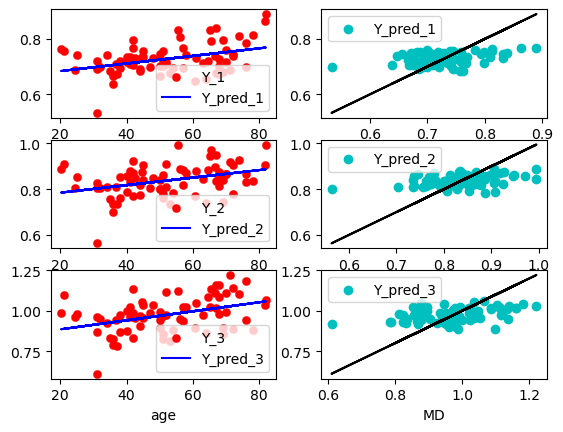

lh_hOc4v_mpm_vpnl
Weights:
[[0.00130116]] [[0.00227074]] [[0.00382073]]
MSE:
0.0020988294709610136 0.003879496656826893 0.009274450458202037
R2:
0.1629155598178409 0.2428140232327557 0.2752390478391219


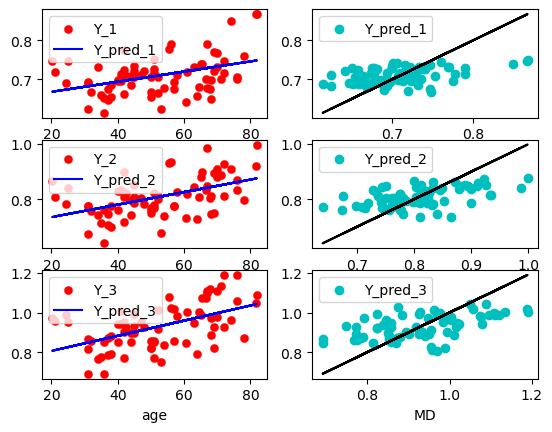

lh_MT_exvivo_thresh
Weights:
[[0.00019672]] [[0.00105025]] [[0.00362207]]
MSE:
0.0014445058769047892 0.002733826712535362 0.01136050846142925
R2:
0.0064225497532225395 0.08871137046733846 0.2179127418606268


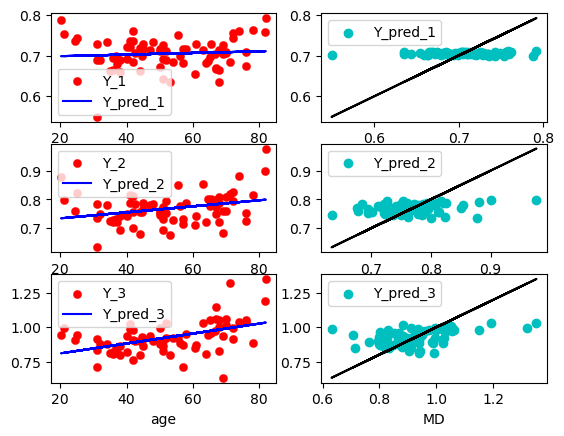

lh_MT_exvivo
Weights:
[[0.00030946]] [[0.00109319]] [[0.00371956]]
MSE:
0.0014892648355338605 0.0020556096280477812 0.007126914760731012
R2:
0.015278002523405054 0.12301334669335628 0.3189747570139694


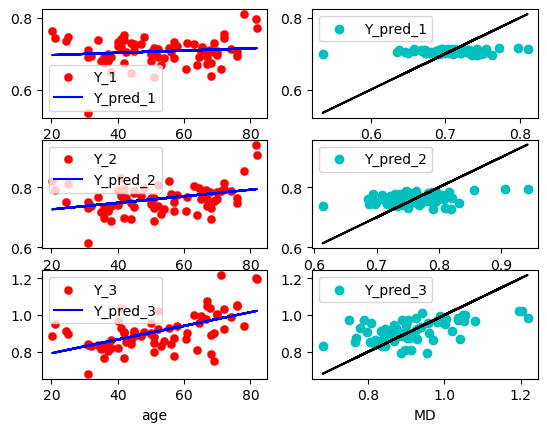

lh_nofix_cortex
Weights:
[[0.00071275]] [[0.0013067]] [[0.00347954]]
MSE:
0.0005176683278405029 0.0009209232937674504 0.002369509344701958
R2:
0.19144680577850082 0.30907713460479025 0.5521344563666197


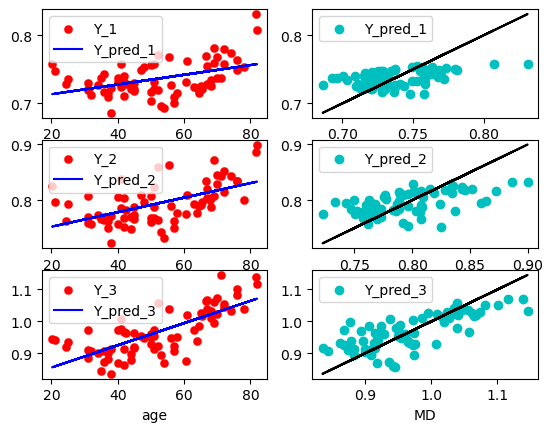

lh_perirhinal_exvivo_thresh
Weights:
[[0.00032348]] [[0.00056951]] [[0.00168602]]
MSE:
0.002906945396009888 0.003133604998614474 0.00385734290574691
R2:
0.008609998793857043 0.02436472342990037 0.1509649294400911


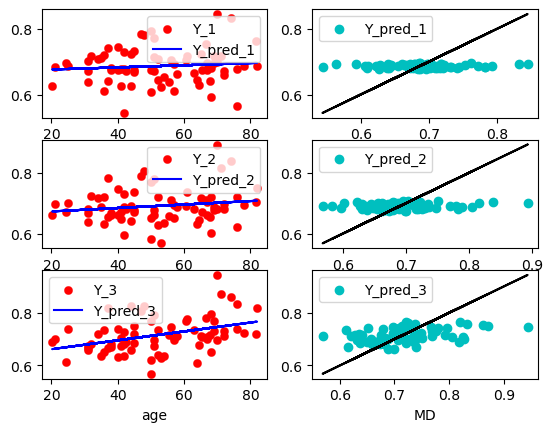

lh_perirhinal_exvivo
Weights:
[[0.00028187]] [[0.00080362]] [[0.00213039]]
MSE:
0.0024174392142955283 0.002884962020522423 0.004280303423138634
R2:
0.00786720252790607 0.05124265300691766 0.20371511491906724


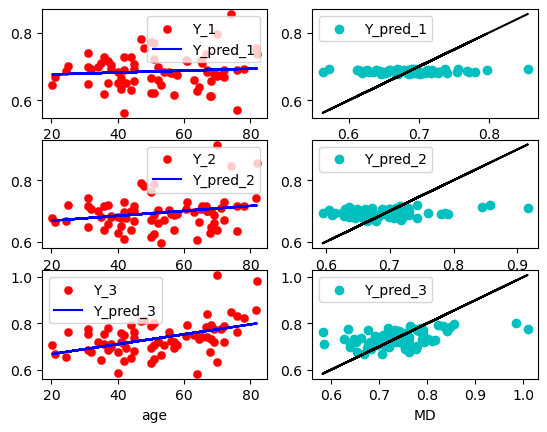

lh_V1_exvivo_thresh
Weights:
[[0.00142433]] [[0.00246227]] [[0.00398797]]
MSE:
0.0025686840350956216 0.0030780040256485697 0.007488534786796046
R2:
0.16005637161200104 0.3221445424678653 0.33880394587208273


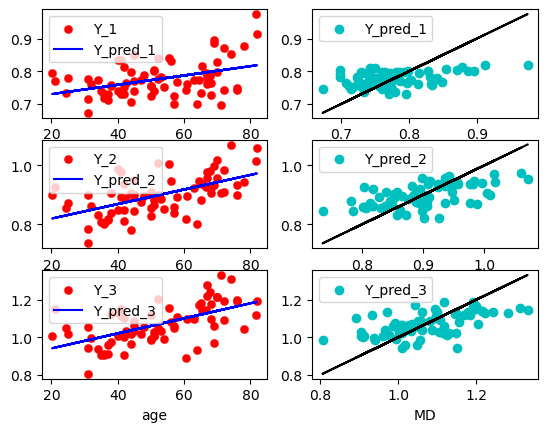

lh_V1_exvivo
Weights:
[[0.0013228]] [[0.00231342]] [[0.0037388]]
MSE:
0.0021544453679918207 0.003128496480975217 0.007901619590733844
R2:
0.16384999153754354 0.29215939849476613 0.2991484908550496


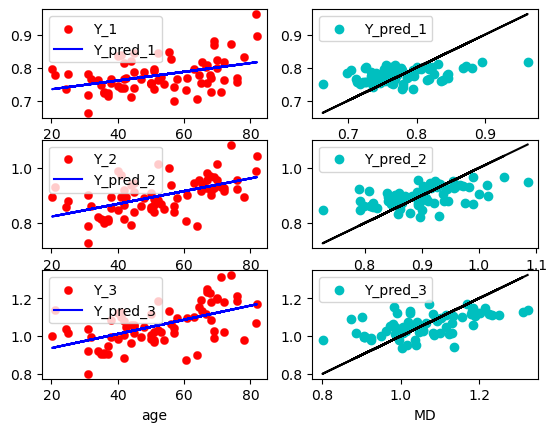

lh_V2_exvivo_thresh
Weights:
[[0.00130845]] [[0.0020951]] [[0.00332914]]
MSE:
0.0018305814919406219 0.004262172718592384 0.009547932108094655
R2:
0.1841077559983022 0.1990248295455601 0.21879249230715891


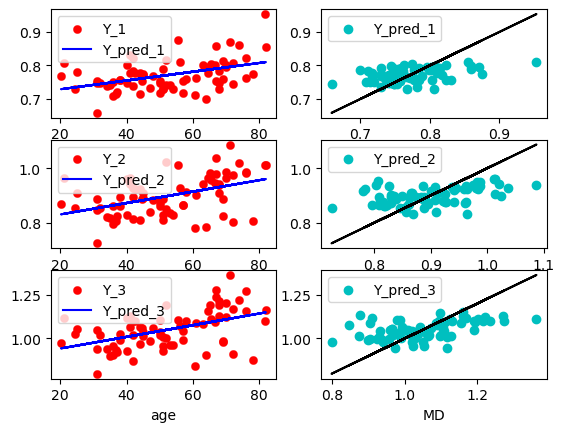

lh_V2_exvivo
Weights:
[[0.00122623]] [[0.00204341]] [[0.00360395]]
MSE:
0.0015031143475606767 0.0029784216096364765 0.007080994877501263
R2:
0.19443041068307454 0.2527556842311125 0.30678952883489574


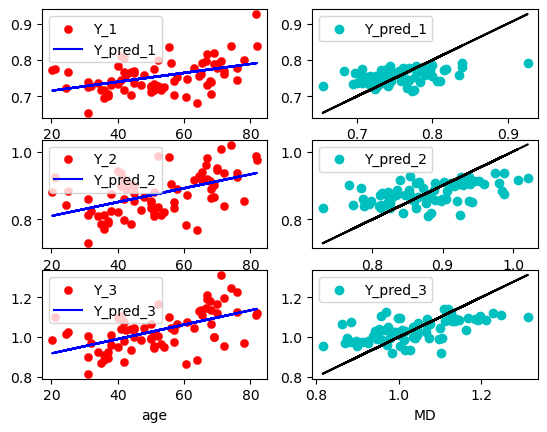

In [10]:
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y_1 = left_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = left_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = left_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    print('Weights:')
    print(weights_1, weights_2, weights_3)
    print('MSE:')
    print(mse_1, mse_2, mse_3)
    print('R2:')
    print(r2_1, r2_2, r2_3)
    plt.subplot(3, 2, 1)
    plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 2)
    plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
    plt.plot(Y_1[:,0], Y_1[:,0], color='k')
    plt.legend()
    plt.xlabel('MD')
    plt.subplot(3, 2, 3)
    plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 4)
    plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
    plt.plot(Y_2[:,0], Y_2[:,0], color='k')
    plt.legend()
    plt.xlabel('MD')
    plt.subplot(3, 2, 5)
    plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 6)
    plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
    plt.plot(Y_3[:,0], Y_3[:,0], color='k')
    plt.legend()
    plt.xlabel('MD')

    plt.show()


rh_BA1_exvivo_thresh
Weights:
[[-0.0008706]] [[-0.00076668]] [[6.80936997e-05]]
MSE:
0.0014132702102254801 0.005686037479502536 0.01764562074009035
R2:
0.11457251431614168 0.024335114082584597 6.339588149162356e-05


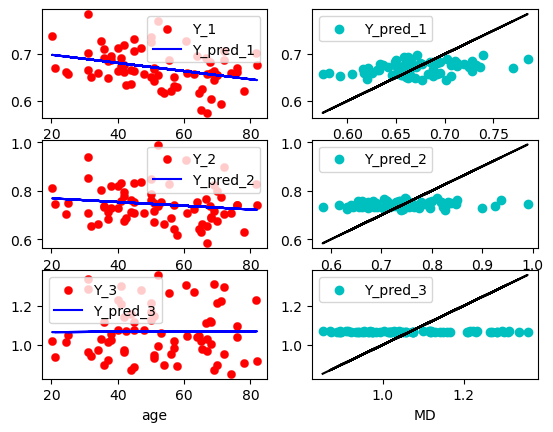

rh_BA1_exvivo
Weights:
[[-0.0003719]] [[0.00015453]] [[0.00198004]]
MSE:
0.0015943156076989931 0.0038122171033748136 0.0062650541630542384
R2:
0.020501481170049796 0.0015090158603324744 0.1311790896079459


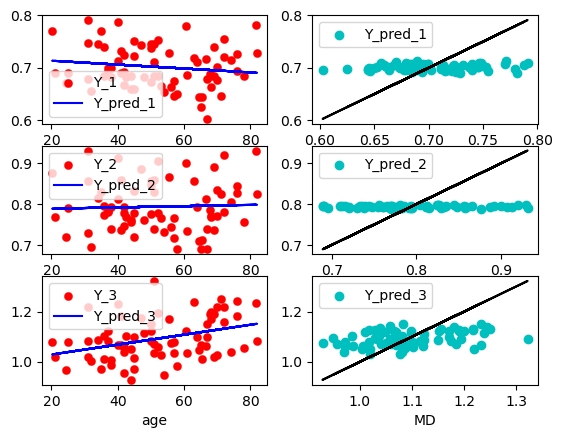

rh_BA2_exvivo_thresh
Weights:
[[0.00022698]] [[0.00080093]] [[0.00332809]]
MSE:
0.0010123589237936244 0.003009066068138369 0.01945320590680349
R2:
0.012129273006292407 0.04891982549880769 0.12078299838549988


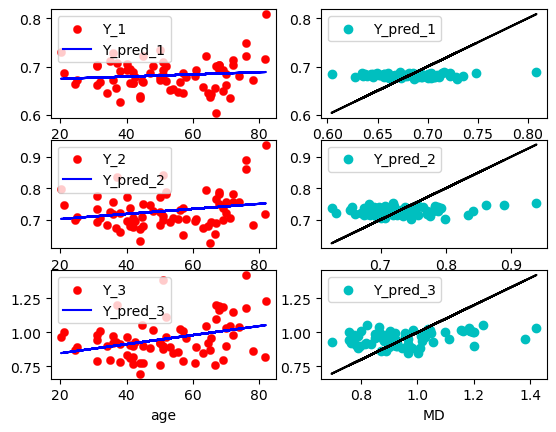

rh_BA2_exvivo
Weights:
[[-0.00017317]] [[0.00043925]] [[0.00266737]]
MSE:
0.0012172845032608869 0.0027243706095361067 0.005407970292348347
R2:
0.005908825177846744 0.016800410283135614 0.24094464047514363


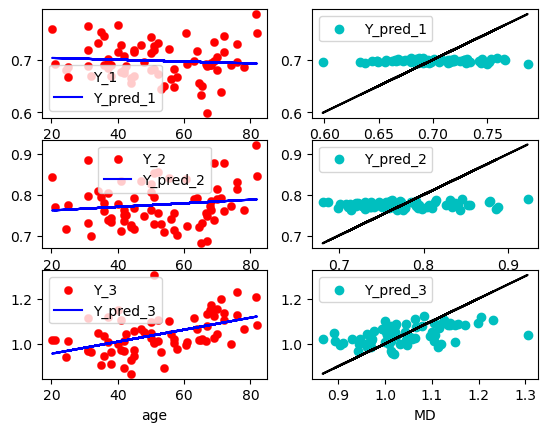

rh_BA3a_exvivo_thresh
Weights:
[[-0.00084189]] [[9.95193706e-05]] [[0.00338558]]
MSE:
0.0019454043963813327 0.004729890849915314 0.011894157205720197
R2:
0.08080188213308759 0.0005049593558152932 0.18864855401966374


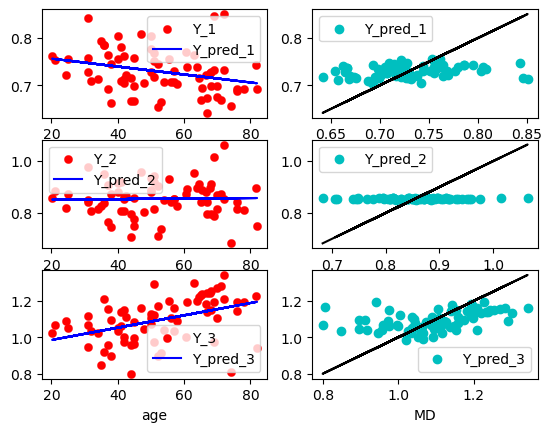

rh_BA3a_exvivo
Weights:
[[-0.00064803]] [[0.00021688]] [[0.00378154]]
MSE:
0.0025574827380633147 0.004870898005208967 0.008784947989310345
R2:
0.03810848294888414 0.002324480195293299 0.2819936034224463


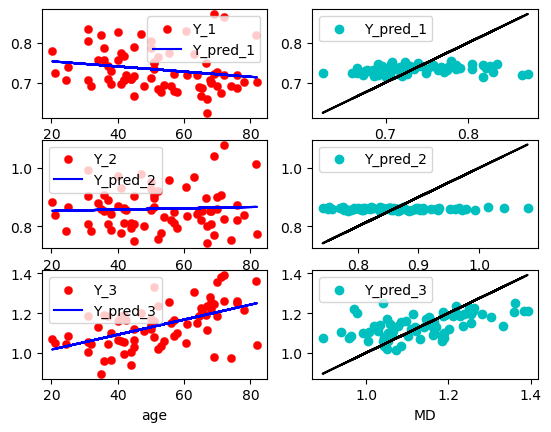

rh_BA3b_exvivo_thresh
Weights:
[[-0.00084914]] [[0.0007241]] [[0.00494264]]
MSE:
0.009744840500689802 0.021213978019858734 0.027687126592861624
R2:
0.017539287276514326 0.005927982043861468 0.17552196649789953


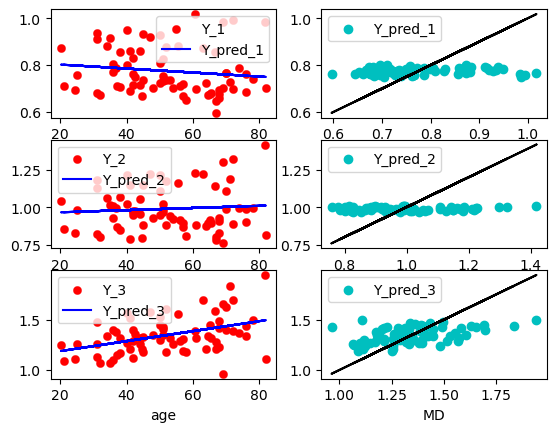

rh_BA3b_exvivo
Weights:
[[-0.00074473]] [[0.00027038]] [[0.0032971]]
MSE:
0.004109017087224358 0.009727746922242965 0.01482887773322973
R2:
0.03153973919501196 0.0018099754292036918 0.15029210233226598


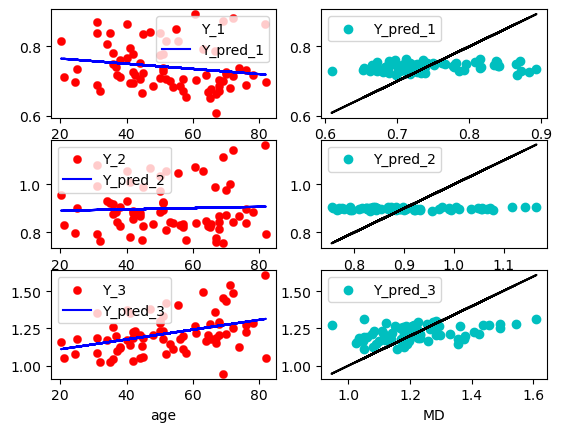

rh_BA4a_exvivo_thresh
Weights:
[[0.0001449]] [[0.00061443]] [[0.00159249]]
MSE:
0.0011057136567204457 0.003197645337376325 0.007933958686840582
R2:
0.004560300364670922 0.027696444639981554 0.07159938147654288


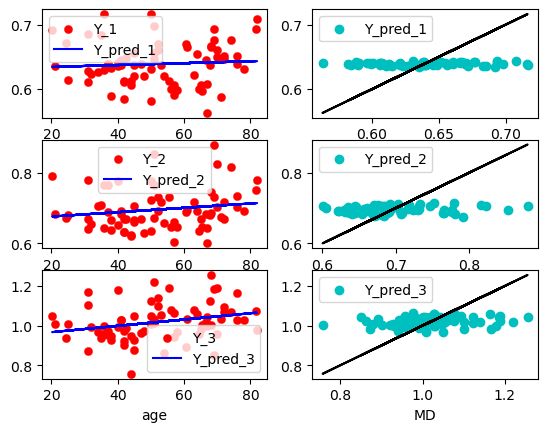

rh_BA4a_exvivo
Weights:
[[-7.45031617e-05]] [[0.0001642]] [[0.00265601]]
MSE:
0.0008529984371887169 0.0015346676963338586 0.008201718176399912
R2:
0.0015675864468874812 0.004220753938789401 0.17185863141240543


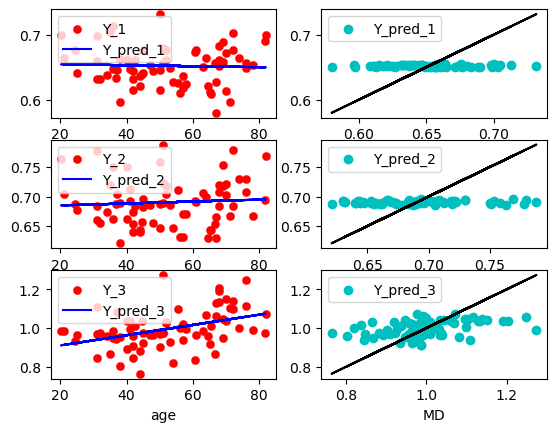

rh_BA4p_exvivo_thresh
Weights:
[[-0.00015953]] [[2.22222342e-05]] [[0.00476577]]
MSE:
0.0007378954733095274 0.001370531777787384 0.018367196078132378
R2:
0.008252751518802892 8.692810949084695e-05 0.22979513271376684


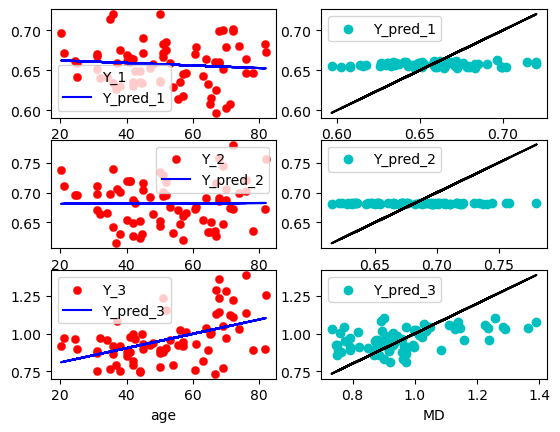

rh_BA4p_exvivo
Weights:
[[-0.00019576]] [[0.00019092]] [[0.00378626]]
MSE:
0.0006915067582766131 0.0012331023694421405 0.01172684258607733
R2:
0.013194806894870847 0.007081655443956003 0.22777103482453842


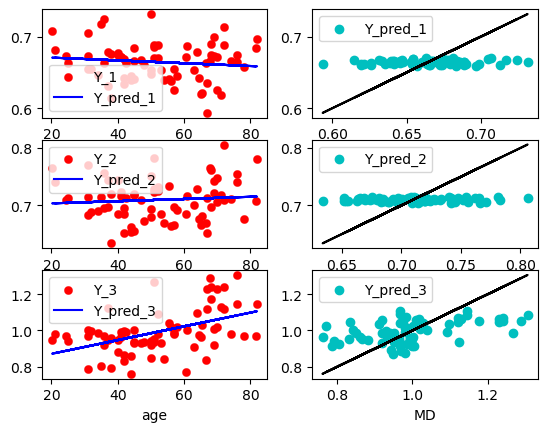

rh_BA6_exvivo_thresh
Weights:
[[-0.00029599]] [[-0.00017863]] [[0.00156689]]
MSE:
0.0009149044128494386 0.0015852320634989453 0.005763590655995928
R2:
0.022582645817021074 0.004833267514133599 0.09319864221392515


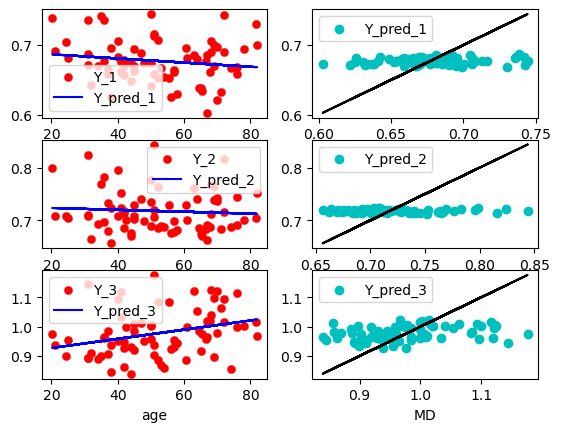

rh_BA6_exvivo
Weights:
[[-0.00022494]] [[9.61890979e-05]] [[0.00221337]]
MSE:
0.000790430989923484 0.001306657606257468 0.004621801683388831
R2:
0.015209443432709135 0.0017055333809888884 0.20366074062801975


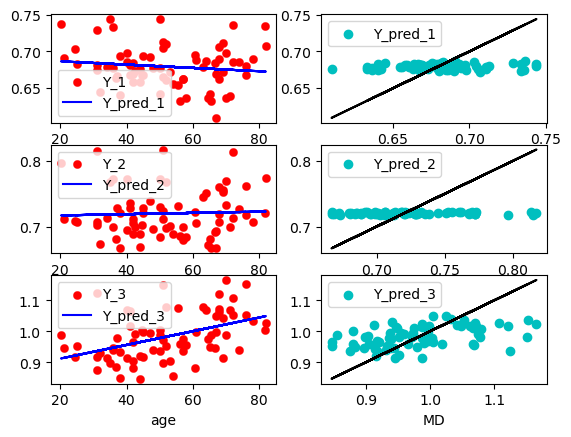

rh_BA44_exvivo_thresh
Weights:
[[0.00018283]] [[0.00078961]] [[0.00269009]]
MSE:
0.0008613724931684777 0.0017863130181571783 0.004797307197128518
R2:
0.009275927365878123 0.07767258301883195 0.2668383340225574


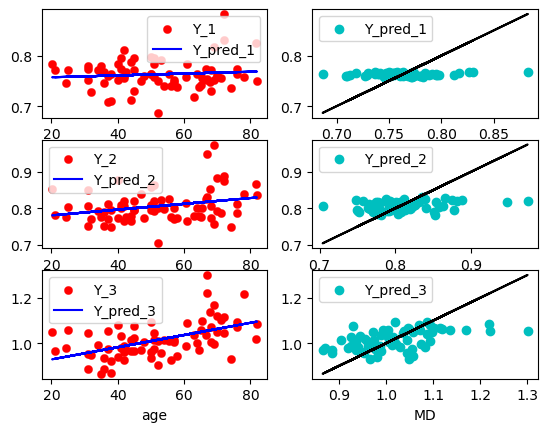

rh_BA44_exvivo
Weights:
[[-4.77293238e-05]] [[0.00071016]] [[0.00369605]]
MSE:
0.0007016350170332747 0.001094228861733974 0.0033486796618791706
R2:
0.0007827640686729476 0.10007408763348868 0.4960354808240365


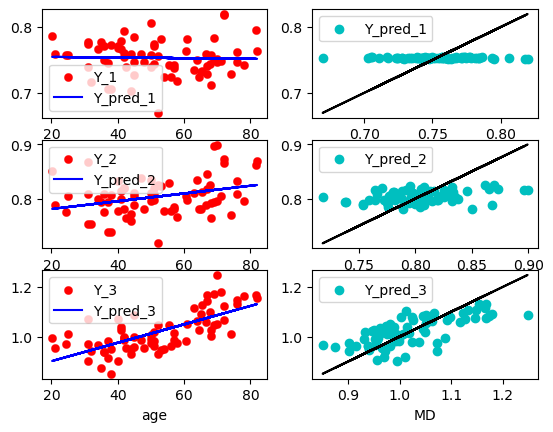

rh_BA45_exvivo_thresh
Weights:
[[0.00026003]] [[0.00095789]] [[0.00355161]]
MSE:
0.001092844790257114 0.0031710031799165243 0.009430019173816757
R2:
0.014708574753367287 0.06525887475218406 0.24399213028343036


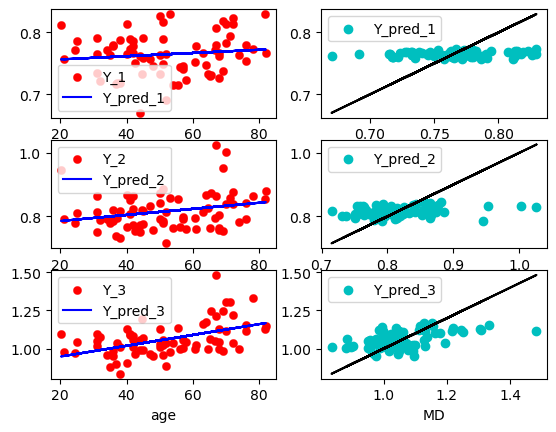

rh_BA45_exvivo
Weights:
[[0.00026116]] [[0.0008849]] [[0.00339181]]
MSE:
0.0007602399742243402 0.0013949753021135403 0.004002469034685967
R2:
0.02118678192158374 0.11927977194530037 0.40950709075835023


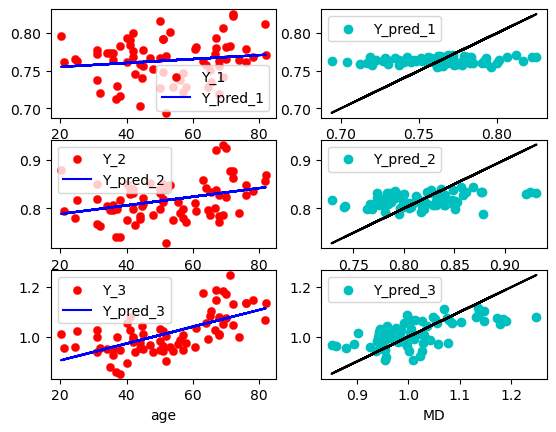

rh_cortex
Weights:
[[0.00036326]] [[0.00100763]] [[0.00343904]]
MSE:
0.0003892301597343084 0.0007374113780896489 0.002177403532100968
R2:
0.07561357850672135 0.24936444190723484 0.5671988328754769


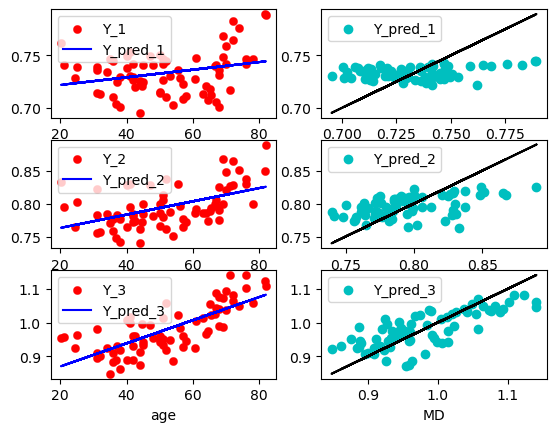

rh_cortex+hipamyg
Weights:
[[0.00034386]] [[0.00098547]] [[0.00340072]]
MSE:
0.0003817361076423854 0.0007205701416707558 0.002123216881363748
R2:
0.0695366960855176 0.24538597738948353 0.5678833233540457


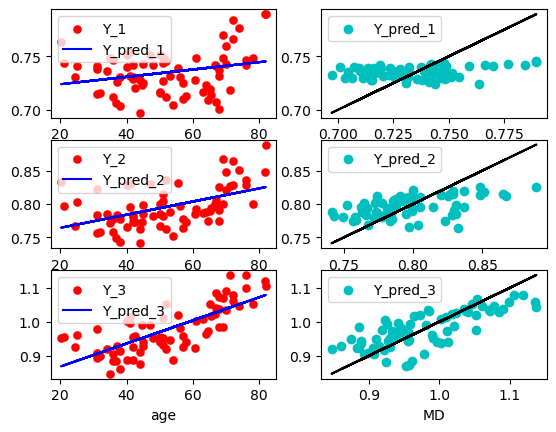

rh_entorhinal_exvivo_thresh
Weights:
[[0.00067524]] [[0.00146421]] [[0.00368004]]
MSE:
0.002740892834577307 0.004212332167319007 0.007109405782225191
R2:
0.03858731230417767 0.10936821454419765 0.31488198284389435


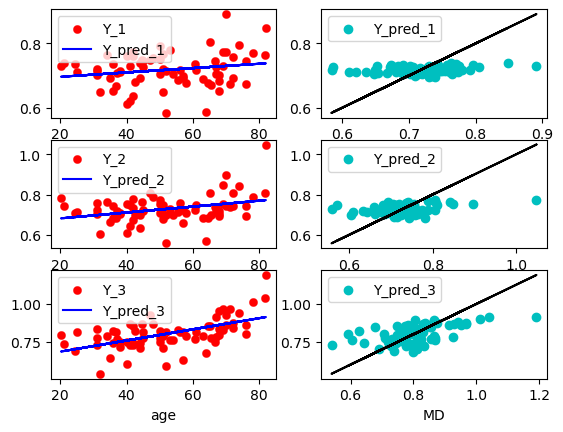

rh_entorhinal_exvivo
Weights:
[[0.00075658]] [[0.00151673]] [[0.00333981]]
MSE:
0.0021374318788148616 0.00317670664732073 0.005644353605525099
R2:
0.060692987711782886 0.1487361880400241 0.32286222528820563


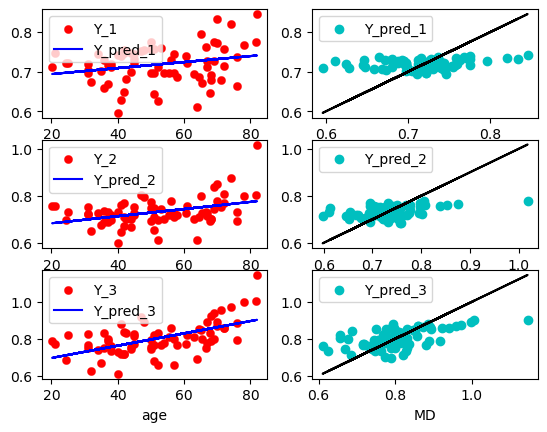

rh_FG1_mpm_vpnl
Weights:
[[0.00103062]] [[0.00245782]] [[0.00576045]]
MSE:
0.0016410951728731285 0.0037102093523478253 0.009707361388623565
R2:
0.13506969991369489 0.28204146430640975 0.4519798750285289


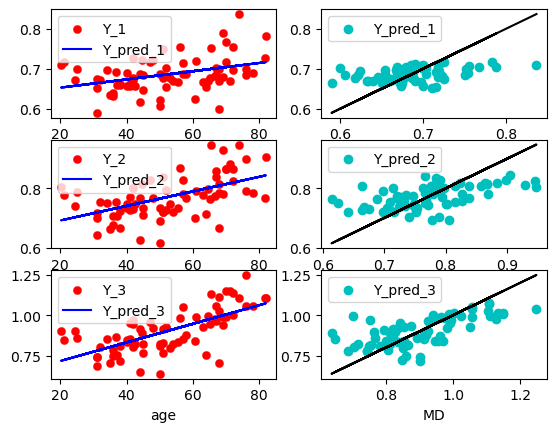

rh_FG2_mpm_vpnl
Weights:
[[0.00068535]] [[0.00173574]] [[0.00422616]]
MSE:
0.0011616850564329403 0.002285478620998281 0.005792157591964317
R2:
0.08888474611233699 0.24130805182550585 0.42659957086137756


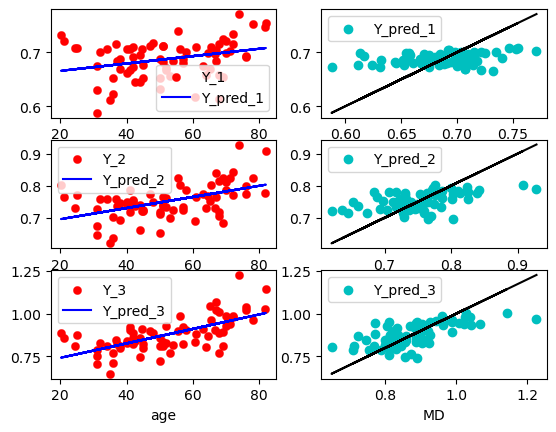

rh_FG3_mpm_vpnl
Weights:
[[0.00045094]] [[0.00189823]] [[0.00545685]]
MSE:
0.001082301782863271 0.0023622479555162395 0.00772657271758982
R2:
0.043365672208719785 0.2690217273850307 0.481822602754979


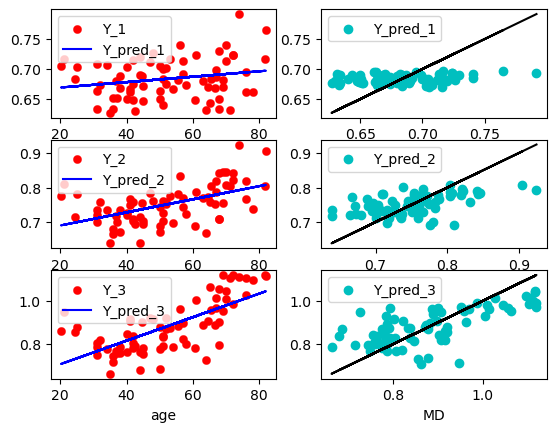

rh_FG4_mpm_vpnl
Weights:
[[0.00059692]] [[0.00120507]] [[0.00420381]]
MSE:
0.0009881688997735057 0.0016689175119655782 0.005505448308973511
R2:
0.08003538251284226 0.17351554277072645 0.4364515961822938


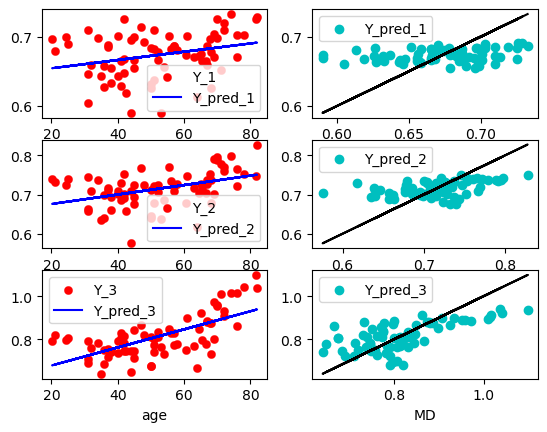

rh_hOc1_mpm_vpnl
Weights:
[[0.00133854]] [[0.00263452]] [[0.004602]]
MSE:
0.0020977182020872976 0.003395655084196448 0.007707465006670016
R2:
0.17086420139811043 0.33028049544532334 0.3986654995598604


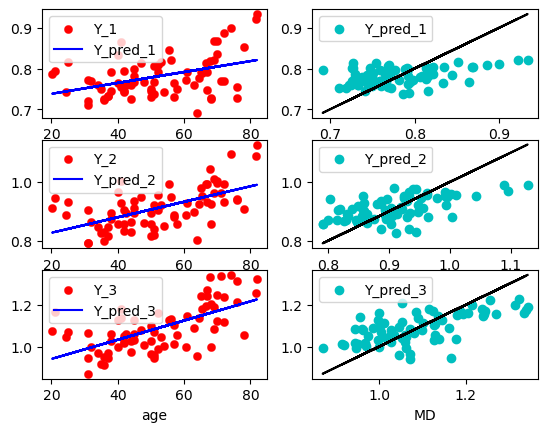

rh_hOc2_mpm_vpnl
Weights:
[[0.00077853]] [[0.00170855]] [[0.00367985]]
MSE:
0.0011671869069590632 0.003304820606651446 0.008502301520329505
R2:
0.11134253758128554 0.17567731216748883 0.27759736771424237


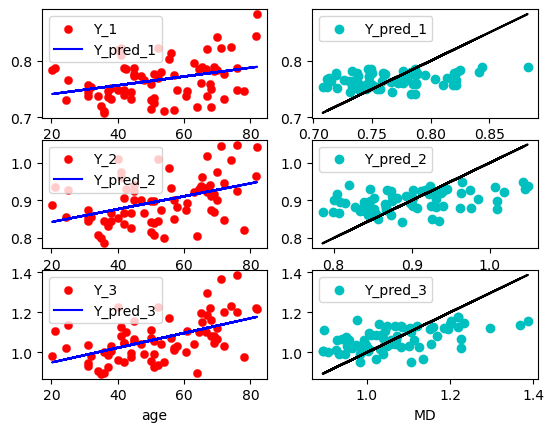

rh_hOc3v_mpm_vpnl
Weights:
[[0.00123476]] [[0.00206762]] [[0.00361761]]
MSE:
0.0020367291258941867 0.004357976562299044 0.011188614517836374
R2:
0.1529803564507064 0.19138602805387672 0.220098979462508


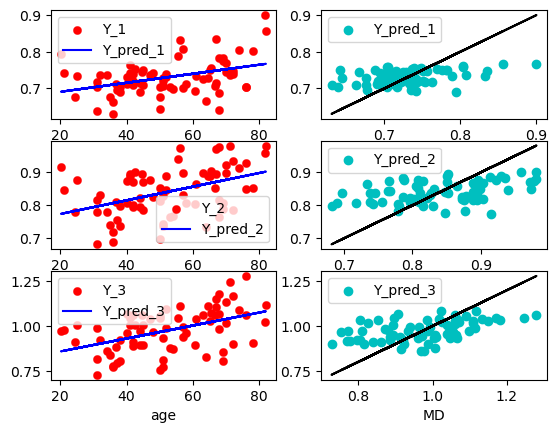

rh_hOc4v_mpm_vpnl
Weights:
[[0.00148433]] [[0.00231734]] [[0.0035527]]
MSE:
0.001907351634441873 0.0033576967867929674 0.010302516813493317
R2:
0.21795711053001177 0.27843485896830533 0.2281490940229114


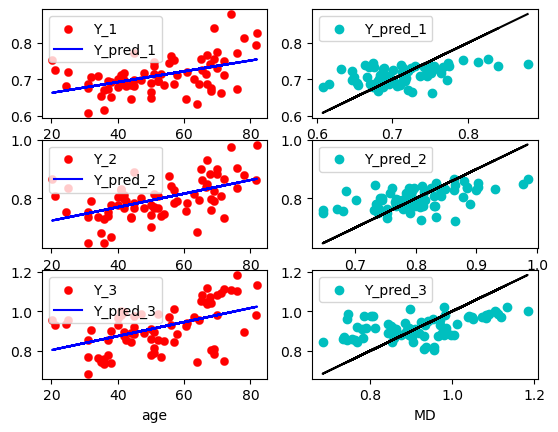

rh_MT_exvivo_thresh
Weights:
[[-0.00027405]] [[0.00048305]] [[0.00448208]]
MSE:
0.0008305662988795031 0.0039008307169648257 0.015724423396225113
R2:
0.02135078674962121 0.014226946308274813 0.23561714537355005


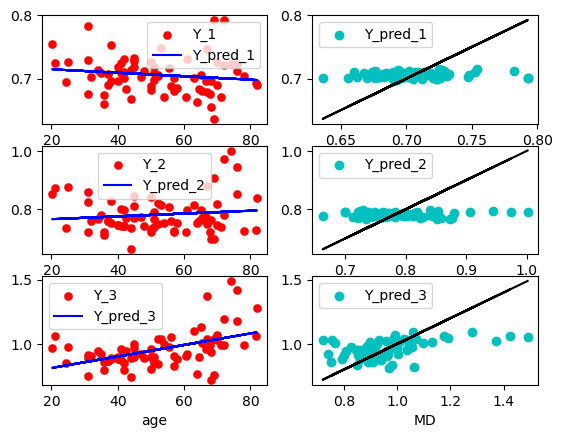

rh_MT_exvivo
Weights:
[[0.00021527]] [[0.00096905]] [[0.00391942]]
MSE:
0.0007503394328339437 0.0013998530801157681 0.005920758903029862
R2:
0.014682053202104695 0.1393054743844908 0.38499638442303663


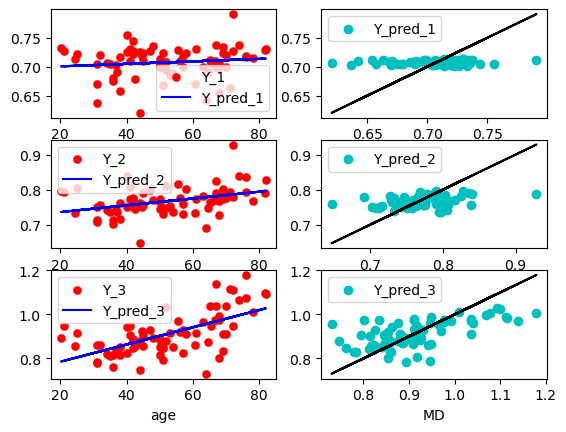

rh_nofix_cortex
Weights:
[[0.00064997]] [[0.00125536]] [[0.00351816]]
MSE:
0.0004604685283225608 0.0008035565938890196 0.0021535960089147845
R2:
0.18124217353390315 0.32119822987328783 0.5810096019458357


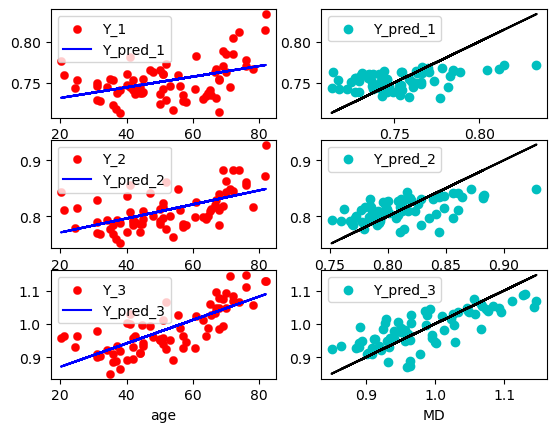

rh_perirhinal_exvivo_thresh
Weights:
[[0.00038972]] [[0.0008882]] [[0.00268142]]
MSE:
0.002714113252029827 0.0029862291854197494 0.003998216321774368
R2:
0.013321904705762777 0.05991998445614022 0.3025944452392192


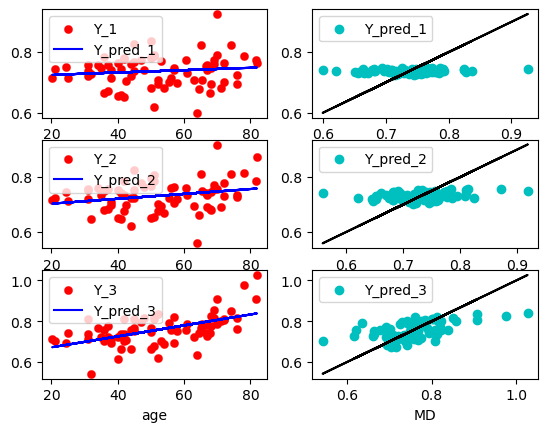

rh_perirhinal_exvivo
Weights:
[[0.00072626]] [[0.00121868]] [[0.00267196]]
MSE:
0.0026046939829875355 0.003252006594160445 0.00519059572055432
R2:
0.04658302432778527 0.09925245709411279 0.24916999019949038


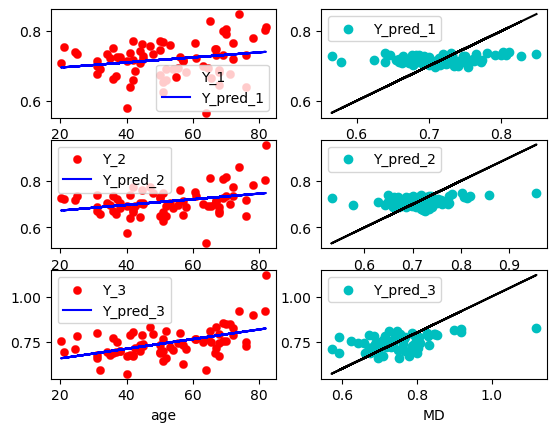

rh_V1_exvivo_thresh
Weights:
[[0.0013993]] [[0.00262211]] [[0.00448734]]
MSE:
0.0022213034159943666 0.0035539858570361837 0.00824787579866098
R2:
0.17537934575300196 0.3182267015808059 0.3706909015310439


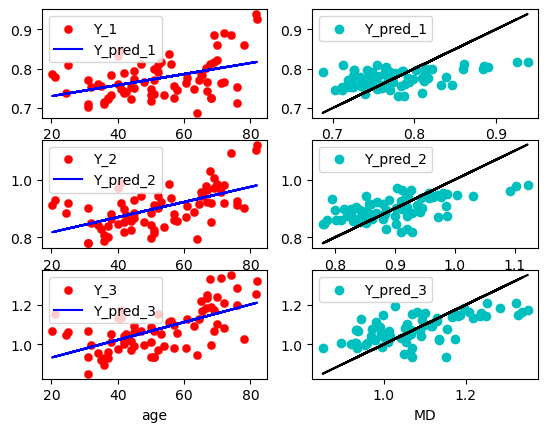

rh_V1_exvivo
Weights:
[[0.00122231]] [[0.00241031]] [[0.0042536]]
MSE:
0.0017947245733115724 0.003328948537536124 0.007928811059772061
R2:
0.1672580251933775 0.2963027752606816 0.3550781896259082


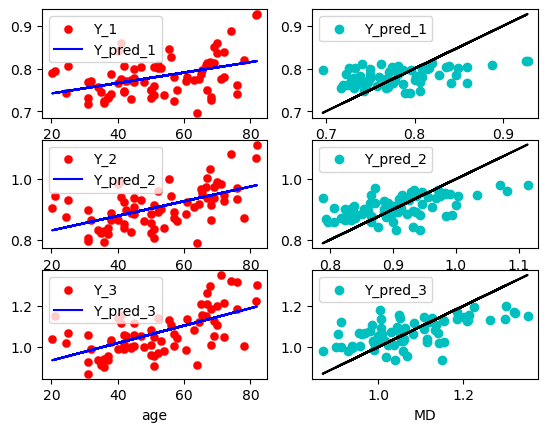

rh_V2_exvivo_thresh
Weights:
[[0.00100076]] [[0.00202292]] [[0.00396322]]
MSE:
0.0015282016931564156 0.0038779315187764674 0.008497322974284802
R2:
0.1365318859836383 0.2029371244196687 0.3084325943600039


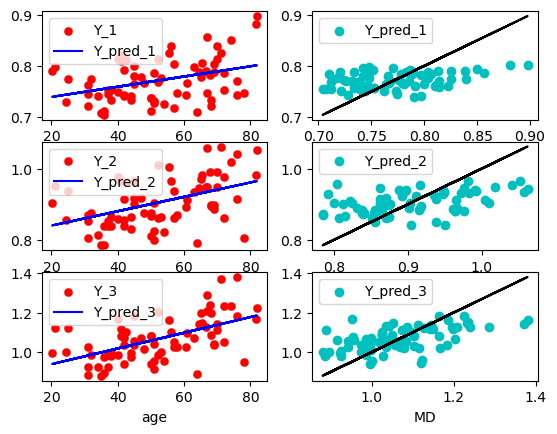

rh_V2_exvivo
Weights:
[[0.00100478]] [[0.00208518]] [[0.0041678]]
MSE:
0.0011274637728026762 0.0027743655227695 0.007383430540860849
R2:
0.17766541917538292 0.27437663840477033 0.36209495120173474


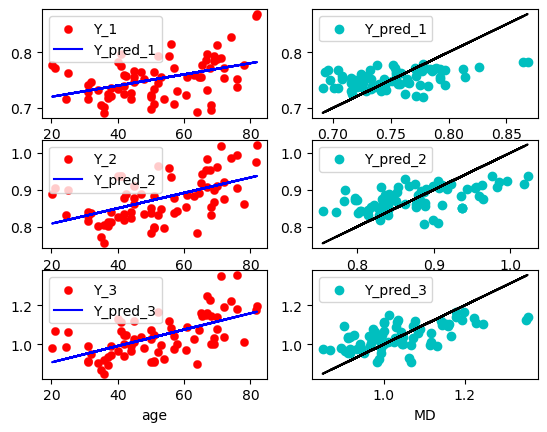

In [11]:
# For left hemisphere
for region in region_list:
    print('rh_' + region)
    Y_1 = right_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = right_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = right_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    print('Weights:')
    print(weights_1, weights_2, weights_3)
    print('MSE:')
    print(mse_1, mse_2, mse_3)
    print('R2:')
    print(r2_1, r2_2, r2_3)
    plt.subplot(3, 2, 1)
    plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 2)
    plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
    plt.plot(Y_1[:,0], Y_1[:,0], color='k')
    plt.legend()
    plt.xlabel('MD')
    plt.subplot(3, 2, 3)
    plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 4)
    plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
    plt.plot(Y_2[:,0], Y_2[:,0], color='k')
    plt.legend()
    plt.xlabel('MD')
    plt.subplot(3, 2, 5)
    plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
    plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
    plt.legend()
    plt.xlabel('age')
    plt.subplot(3, 2, 6)
    plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
    plt.plot(Y_3[:,0], Y_3[:,0], color='k')
    plt.legend()
    plt.xlabel('MD')

    plt.show()
